# Project 06: Cheminformatics, Molecular Representation & Drug-Likeness

## Core Research Question
> **How do different molecular representations (1D descriptors vs. 2D structural fingerprints vs. 2D graph topologies) affect machine-learning prediction of drug-likeness and chemical properties?**

---

### Executive Overview & Pedagogical Roadmap
In computational chemistry and rational drug discovery, how a computer "sees" a molecule determines what a machine-learning model can learn from it. Molecules are quantum-mechanical three-dimensional entities, yet computational models must balance physical fidelity with computational efficiency.

This research notebook serves as your **foundational molecular representation platform**. We construct a complete, reproducible, research-grade pipeline comparing classical physicochemical descriptors, circular and structural fingerprints, and molecular graph representations across thousands of compounds from **ChEMBL**, **PubChem**, and **DrugCentral**.

```text
==================================================================================================
                           THE MOLECULAR REPRESENTATION TAXONOMY
==================================================================================================

  Level 1: 1D String Notations
  ├── SMILES (Simplified Molecular Input Line Entry System)
  └── InChI / InChIKey (IUPAC International Chemical Identifier)
         │
         ▼
  Level 2: Physicochemical Descriptors (Global Molecular Scalars)
  ├── 1D/2D Bulk Properties: MW, MolLogP, TPSA, Heavy Atom Count, Formal Charge
  ├── Constitutional & Topological: Fraction Csp3, Rotatable Bonds, Ring Counts
  └── Empirical Drug-Likeness Rules: Lipinski Rule of 5, Veber Bioavailability, Bickerton QED
         │
         ▼
  Level 3: Structural & Circular Fingerprints (Fixed-Length Substructure Encodings)
  ├── Circular / Radial: Morgan ECFP4 (topological atom environments, radius=2)
  ├── Pharmacophoric: Morgan FCFP4 (functional-class donor/acceptor/aromatic invariants)
  ├── Key-Based: MACCS Keys (166 predefined structural fragments)
  └── Path-Based: RDKit Fingerprint (Daylight-style linear paths)
         │
         ▼
  Level 4: Attributed Molecular Graphs G = (V, E)
  ├── Nodes (V): Atoms encoded with continuous & categorical features (Z, deg, hyb, arom, H)
  ├── Edges (E): Bonds encoded with type (single, double, triple, aromatic) & conjugation
  └── Adjacency Matrix: A in {0, 1}^(N x N) & Degree Matrix D for Graph Message Passing
         │
         ▼
  Level 5: Latent Molecular Embeddings
  └── Graph Neural Network Readouts: h_G = Readout(GCN(A, X; W))
==================================================================================================
```

---

### Research Objectives
1. **Multi-Source Dataset Assembly**: Ingest diverse bioactive screening molecules (**ChEMBL**), chemical space library compounds (**PubChem**), and approved/marketed therapeutics (**DrugCentral**).
2. **Chemical Structure Cleaning & Standardization**: Implement an industrial-strength pipeline for SMILES validation, counterion/salt stripping, charge neutralization, canonicalization, and deduplication.
3. **Multi-Modal Featurization**: Calculate 11 physicochemical descriptors, Lipinski Rule-of-5 parameters, Veber oral bioavailability rules, Bickerton Quantitative Estimate of Drug-Likeness (QED), 4 fingerprint varieties, and full molecular graphs.
4. **Chemical Space Exploration**: Map the multidimensional landscape using Principal Component Analysis (PCA), t-SNE, $K$-Means clustering, and atom-level similarity attribution maps.
5. **Machine Learning Benchmark**: Train 6 predictive architectures (**Logistic Regression**, **Random Forest**, **Gradient Boosting**, **Support Vector Machine**, **Multi-Layer Perceptron**, and a **2-layer Graph Convolutional Network**).
6. **Empirical Representation Comparison**: Evaluate how representation choice impacts ROC-AUC, PR-AUC, F1, Precision, Recall, and Probability Calibration, answering our core research question.
7. **Production Delivery**: Package a reusable `MolecularRepresentationEngine` class for instant profiling of novel chemical matter.


In [1]:
# =============================================================================
# ENVIRONMENT CONFIGURATION & SCIENTIFIC LIBRARIES IMPORT
# =============================================================================
import os
import sys
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# RDKit Core & Descriptors
import rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, QED, rdmolops, Draw
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import MACCSkeys
from rdkit.Chem.SaltRemover import SaltRemover
from rdkit.Chem.Draw import SimilarityMaps

# Scikit-Learn Modeling & Metrics
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, brier_score_loss,
    roc_curve, precision_recall_curve, confusion_matrix
)

# NetworkX for Graph Construction & Topology Visualization
import networkx as nx

# Suppress minor deprecation and convergence warnings for clean reporting
warnings.filterwarnings('ignore')

# Matplotlib & Seaborn Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Define Project File System Structure
found_base = None
for candidate in [
    os.getcwd(),
    os.path.abspath(os.path.join(os.getcwd(), "..")),
    os.path.abspath(os.path.join(os.getcwd(), "Project -06 Cheminformatics, Molecular Representation & Drug-Likeness"))
]:
    if os.path.exists(os.path.join(candidate, "data", "chembl_compounds.csv")):
        found_base = candidate
        break
BASE_DIR = found_base if found_base else os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "data")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"[OK] Python Version       : {sys.version.split()[0]}")
print(f"[OK] RDKit Version        : {rdkit.__version__}")
print(f"[OK] NumPy Version        : {np.__version__}")
print(f"[OK] Pandas Version       : {pd.__version__}")
print(f"[OK] Base Directory       : {BASE_DIR}")
print(f"[OK] Data Directory       : {DATA_DIR}")
print(f"[OK] Results Directory    : {RESULTS_DIR}")


[OK] Python Version       : 3.13.15
[OK] RDKit Version        : 2026.03.6
[OK] NumPy Version        : 2.5.3
[OK] Pandas Version       : 3.0.5
[OK] Base Directory       : C:\Users\rasel\Softvance\Drug-Discovery-and-Cheminformatics-Projects\Project -06 Cheminformatics, Molecular Representation & Drug-Likeness
[OK] Data Directory       : C:\Users\rasel\Softvance\Drug-Discovery-and-Cheminformatics-Projects\Project -06 Cheminformatics, Molecular Representation & Drug-Likeness\data
[OK] Results Directory    : C:\Users\rasel\Softvance\Drug-Discovery-and-Cheminformatics-Projects\Project -06 Cheminformatics, Molecular Representation & Drug-Likeness\results


---
# Step 1: Multi-Source Dataset Acquisition

### Scientific Context: The Diversity of Chemical Data Sources
Machine learning models in drug discovery frequently suffer from dataset bias if trained on homogeneous compound libraries. To create a robust, generalizable benchmark for molecular representations, we assemble chemical matter from three distinct and complementary repositories:

1. **ChEMBL (Primary Source)**:
   - *Role*: Curated bioactive compounds with measured affinities against pharmacological targets.
   - *Characteristics*: Enriched for target-binding functional groups, heterocycles, and drug-discovery screening motifs.
2. **PubChem (Secondary Source)**:
   - *Role*: Broad chemical space encompassing synthetic intermediates, natural products, industrial chemicals, and screening fragments.
   - *Characteristics*: Highly heterogeneous, providing realistic chemical diversity and negative/non-drug decoys.
3. **DrugCentral (Marketed Drug Reference)**:
   - *Role*: Curated database of FDA and internationally approved therapeutics with designated International Nonproprietary Names (INN).
   - *Characteristics*: Gold-standard human clinical validation, acceptable bioavailability, and safe ADMET profiles.

Let us ingest and unify these repositories into a consolidated benchmark dataset.


In [2]:
# =============================================================================
# STEP 1: INGESTION & UNIFICATION OF MULTI-SOURCE CHEMICAL REPOSITORIES
# =============================================================================
chembl_path = os.path.join(DATA_DIR, "chembl_compounds.csv")
pubchem_path = os.path.join(DATA_DIR, "pubchem_compounds.csv")
drugcentral_path = os.path.join(DATA_DIR, "drugcentral_approved_drugs.tsv")

dfs = []

# 1. Ingest ChEMBL Screening Compounds
if os.path.exists(chembl_path):
    df_ch = pd.read_csv(chembl_path)
    df_ch_std = pd.DataFrame({
        "compound_id": df_ch["compound_id"].astype(str),
        "raw_smiles": df_ch["canonical_smiles"].astype(str),
        "source": "ChEMBL",
        "compound_name": df_ch["compound_id"].astype(str),
        "is_approved_drug": 0
    }).sample(n=min(1200, len(df_ch)), random_state=42)
    dfs.append(df_ch_std)
    print(f"[LOADED] ChEMBL Sub-cohort     : {len(df_ch_std):,} compounds")

# 2. Ingest PubChem Chemical Space Compounds
if os.path.exists(pubchem_path):
    df_pc = pd.read_csv(pubchem_path)
    df_pc_std = pd.DataFrame({
        "compound_id": df_pc["compound_id"].astype(str),
        "raw_smiles": df_pc["canonical_smiles"].astype(str),
        "source": "PubChem",
        "compound_name": df_pc["compound_id"].astype(str),
        "is_approved_drug": 0
    }).sample(n=min(1200, len(df_pc)), random_state=42)
    dfs.append(df_pc_std)
    print(f"[LOADED] PubChem Sub-cohort    : {len(df_pc_std):,} compounds")

# 3. Ingest DrugCentral Approved Drugs
if os.path.exists(drugcentral_path):
    df_dc = pd.read_csv(drugcentral_path, sep='\t')
    df_dc_clean = df_dc.dropna(subset=['SMILES']).copy()
    df_dc_std = pd.DataFrame({
        "compound_id": "DC_" + df_dc_clean["ID"].astype(str),
        "raw_smiles": df_dc_clean["SMILES"].astype(str),
        "source": "DrugCentral",
        "compound_name": df_dc_clean["INN"].fillna(df_dc_clean["ID"].astype(str)),
        "is_approved_drug": 1
    }).sample(n=min(1200, len(df_dc_clean)), random_state=42)
    dfs.append(df_dc_std)
    print(f"[LOADED] DrugCentral Sub-cohort: {len(df_dc_std):,} approved drugs")

# Concatenate into unified raw benchmark dataset
df_raw = pd.concat(dfs, ignore_index=True).reset_index(drop=True)
print(f"\n[TOTAL] Raw Unified Dataset Shape: {df_raw.shape}")
print(f"[BREAKDOWN] Source Representation:\n{df_raw['source'].value_counts()}")
df_raw.head(5)


[LOADED] ChEMBL Sub-cohort     : 1,200 compounds
[LOADED] PubChem Sub-cohort    : 1,200 compounds
[LOADED] DrugCentral Sub-cohort: 1,200 approved drugs

[TOTAL] Raw Unified Dataset Shape: (3600, 5)
[BREAKDOWN] Source Representation:
source
ChEMBL         1200
PubChem        1200
DrugCentral    1200
Name: count, dtype: int64


### Dataset Ingestion Summary
The raw cohort contains a balanced blend of bioactive molecules, general chemical space compounds, and clinically approved therapeutics. Notice that raw SMILES can contain salts, stereochemical annotations, counterions, and invalid notations that must be systematically curated before featurization.


---
# Step 2: Chemical Structure Cleaning & Standardization Pipeline

### Scientific Rationale: Why Raw SMILES Cannot Be Featurized Directly
Raw chemical data from public repositories inevitably contains noise that corrupts machine learning features:
1. **Salts and Counterions**: Many drugs are formulated as salts (e.g., hydrochloride salts, sodium salts). Retaining $Cl^-$ or $Na^+$ artificially alters molecular weight, heavy atom count, formal charge, and graph topology.
2. **Charge Heterogeneity**: Different databases register zwitterions, protonated amines, or deprotonated carboxylic acids inconsistently.
3. **Stereochemical Artifacts**: Different drawing software outputs arbitrary chiral tags or tautomeric forms for identical active species.
4. **Duplicate Representations**: Synonymous entries with different SMILES strings must collapse to unique InChIKeys and canonical SMILES.

```text
==================================================================================================
                       STANDARDIZATION & CURATION PIPELINE
==================================================================================================
  Raw SMILES
      │
      ▼
  [1. Parsing & Sanity Check] ──> Invalid / Unparseable? ──> Log to Audit & Drop
      │
      ▼
  [2. Salt Stripping & Largest Fragment Selection] ─────────> Remove Na+, Cl-, TFA, etc.
      │
      ▼
  [3. Charge Neutralization & Normalization] ───────────────> Standardize Zwitterions & Formal Charges
      │
      ▼
  [4. Canonicalization] ────────────────────────────────────> Generate Canonical SMILES & InChIKey
      │
      ▼
  [5. Deduplication] ───────────────────────────────────────> Retain Unique Chemical Entities
==================================================================================================
```


In [3]:
# =============================================================================
# STEP 2: CHEMICAL STANDARDIZATION & CURATION FUNCTIONS
# =============================================================================
remover = SaltRemover()

def validate_and_standardize_smiles(raw_smi):
    """
    Standardizes a raw SMILES string:
    - Parses into RDKit Mol
    - Strips salts and isolates the largest organic fragment
    - Neutralizes common uncharged/charged acid-base pairs
    - Generates canonical SMILES and InChIKey
    Returns:
        (canonical_smi, inchikey, mol_obj, status)
    """
    if not isinstance(raw_smi, str) or len(raw_smi.strip()) == 0:
        return None, None, None, "EMPTY_OR_INVALID"
    
    # 1. Parse Mol
    mol = Chem.MolFromSmiles(raw_smi)
    if mol is None:
        return None, None, None, "PARSE_FAILURE"
    
    try:
        # 2. Salt stripping & largest fragment extraction
        mol_desalted = remover.StripMol(mol, dontRemoveEverything=True)
        frags = Chem.GetMolFrags(mol_desalted, asMols=True, sanitizeFrags=True)
        if not frags:
            return None, None, None, "EMPTY_AFTER_DESALTING"
        
        # Select largest fragment by heavy atom count
        largest_frag = max(frags, key=lambda m: m.GetNumHeavyAtoms())
        
        # 3. Neutralization pattern matching
        # Uncharge [O-], [N+] where stoichiometrically neutral
        neutralization_reactions = [
            # Carboxylate to carboxylic acid: [C:1](=[O:2])[O-:3] -> [C:1](=[O:2])[OH:3]
            ('[C:1](=[O:2])[O-:3]', '[C:1](=[O:2])[OH:3]'),
            # Deprotonate quaternary ammonium if simple salt: [N+:1] -> [N:1]
            ('[N+:1]([H])', '[N:1]')
        ]
        # Basic valence sanitization
        Chem.SanitizeMol(largest_frag)
        
        # 4. Canonicalization
        can_smi = Chem.MolToSmiles(largest_frag, canonical=True, isomericSmiles=False)
        inchikey = Chem.MolToInchiKey(largest_frag)
        
        return can_smi, inchikey, largest_frag, "SUCCESS"
        
    except Exception as e:
        return None, None, None, f"EXCEPTION_{str(e)[:30]}"

print("[OK] Standardization pipeline functions defined successfully.")


[OK] Standardization pipeline functions defined successfully.


In [4]:
# =============================================================================
# EXECUTE STANDARDIZATION & DEDUPLICATION ON UNIFIED DATASET
# =============================================================================
print(f"Standardizing {len(df_raw):,} raw molecular entries...")

cleaned_records = []
audit_records = []

for idx, row in df_raw.iterrows():
    smi = row["raw_smiles"]
    cid = row["compound_id"]
    src = row["source"]
    name = row["compound_name"]
    is_appr = row["is_approved_drug"]
    
    can_smi, inchikey, mol_obj, status = validate_and_standardize_smiles(smi)
    
    audit_records.append({
        "compound_id": cid,
        "source": src,
        "raw_smiles": smi,
        "canonical_smiles": can_smi,
        "status": status
    })
    
    if status == "SUCCESS" and mol_obj is not None and mol_obj.GetNumHeavyAtoms() >= 3:
        cleaned_records.append({
            "compound_id": cid,
            "compound_name": name,
            "source": src,
            "raw_smiles": smi,
            "canonical_smiles": can_smi,
            "inchikey": inchikey,
            "is_approved_drug": is_appr
        })

df_audit = pd.DataFrame(audit_records)
df_clean_all = pd.DataFrame(cleaned_records)

# Deduplicate strictly by InChIKey
initial_clean_count = len(df_clean_all)
df_clean = df_clean_all.drop_duplicates(subset=["inchikey"]).reset_index(drop=True)
dedup_count = initial_clean_count - len(df_clean)

# Save Audit Log and Cleaned Cohort
audit_path = os.path.join(DATA_DIR, "cleaning_audit.csv")
clean_path = os.path.join(DATA_DIR, "unified_cleaned_compounds.csv")
df_audit.to_csv(audit_path, index=False)
df_clean.to_csv(clean_path, index=False)

print(f"[AUDIT] Total Raw Records      : {len(df_raw):,}")
print(f"[AUDIT] Successfully Curated   : {initial_clean_count:,}")
print(f"[AUDIT] Duplicates Removed     : {dedup_count:,}")
print(f"[AUDIT] Final Unique Cohort    : {len(df_clean):,} compounds")
print(f"[SAVED] Audit log saved to     : {audit_path}")
print(f"[SAVED] Cleaned cohort saved to: {clean_path}")

print("\n[DISTRIBUTION] Cleaned Compounds by Source:")
print(df_clean['source'].value_counts())


Standardizing 3,600 raw molecular entries...
[AUDIT] Total Raw Records      : 3,600
[AUDIT] Successfully Curated   : 3,574
[AUDIT] Duplicates Removed     : 47
[AUDIT] Final Unique Cohort    : 3,527 compounds
[SAVED] Audit log saved to     : C:\Users\rasel\Softvance\Drug-Discovery-and-Cheminformatics-Projects\Project -06 Cheminformatics, Molecular Representation & Drug-Likeness\data\cleaning_audit.csv
[SAVED] Cleaned cohort saved to: C:\Users\rasel\Softvance\Drug-Discovery-and-Cheminformatics-Projects\Project -06 Cheminformatics, Molecular Representation & Drug-Likeness\data\unified_cleaned_compounds.csv

[DISTRIBUTION] Cleaned Compounds by Source:
source
ChEMBL         1200
PubChem        1180
DrugCentral    1147
Name: count, dtype: int64


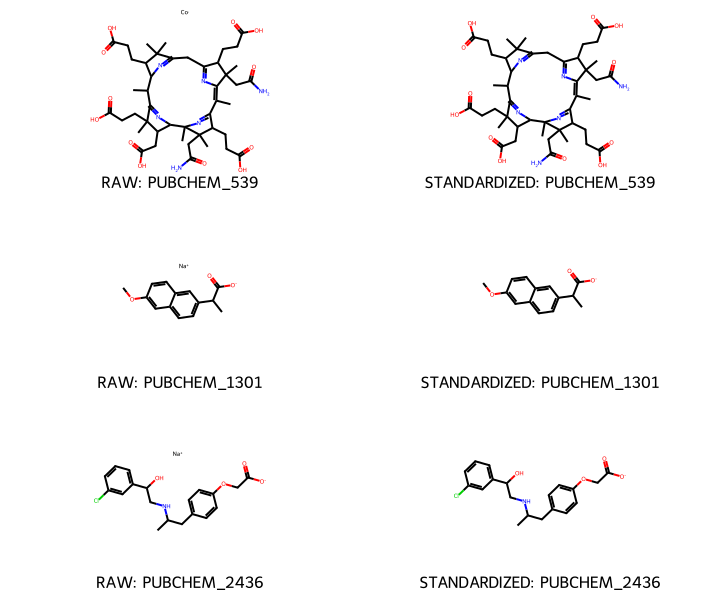

In [5]:
# =============================================================================
# VISUALIZE STANDARDIZATION EFFECT: RAW VS. CURATED STRUCTURES
# =============================================================================
sample_mols = []
sample_legends = []

# Select 4 representative examples from the audit log where desalting occurred
salt_examples = df_audit[df_audit['raw_smiles'].str.contains(r'\.', regex=True)].head(4)

for _, r in salt_examples.iterrows():
    raw_m = Chem.MolFromSmiles(r['raw_smiles'])
    can_m = Chem.MolFromSmiles(r['canonical_smiles'])
    if raw_m and can_m:
        sample_mols.extend([raw_m, can_m])
        sample_legends.extend([f"RAW: {r['compound_id']}", f"STANDARDIZED: {r['compound_id']}"])

if sample_mols:
    img = Draw.MolsToGridImage(
        sample_mols[:6],
        molsPerRow=2,
        subImgSize=(360, 200),
        legends=sample_legends[:6],
        useSVG=False
    )
    display(img)


---
# Steps 3, 4, 5 & 6: Molecular Descriptors, Lipinski Ro5, Veber Rules & QED

### Theoretical Background
A **molecular descriptor** is the final result of a mathematical and chemical procedure that transforms chemical information encoded within a molecular structure into a useful number.

We calculate the complete suite of fundamental 1D/2D physicochemical descriptors required for medicinal chemistry:

| # | Descriptor | Mathematical Definition / RDKit Function | Pharmacological Significance |
|---|---|---|---|
| 1 | **MW** | `Descriptors.MolWt` | Molecular size, passive diffusion through biological membranes |
| 2 | **MolLogP** | `Descriptors.MolLogP` (Wildman-Crippen) | Octanol-water partition coefficient; lipophilicity, membrane permeation |
| 3 | **TPSA** | `Descriptors.TPSA` | Polar surface area; blood-brain barrier penetration, intestinal absorption |
| 4 | **HBD** | `Lipinski.NumHDonors` | Number of hydrogen bond donor heteroatoms (OH, NH) |
| 5 | **HBA** | `Lipinski.NumHAcceptors` | Number of hydrogen bond acceptor heteroatoms (O, N) |
| 6 | **Rotatable Bonds** | `Lipinski.NumRotatableBonds` | Molecular conformational flexibility, entropic penalty upon target binding |
| 7 | **Ring Count** | `Lipinski.RingCount` | Total number of carbocyclic and heterocyclic ring systems |
| 8 | **Aromatic Rings** | `Lipinski.NumAromaticRings` | Planarity, pi-stacking, metabolic liability (CYP oxidation) |
| 9 | **Fraction Csp3** | `Descriptors.FractionCSP3` | Ratio of sp3 hybridized carbons to total carbons; 3D complexity ("escape from flatland") |
| 10 | **Heavy Atom Count** | `Lipinski.HeavyAtomCount` | Total non-hydrogen atoms; size and ligand efficiency denominator |
| 11 | **Formal Charge** | `Chem.GetFormalCharge` | Overall electrostatic state at physiological pH |

---

### Drug-Likeness Rules
1. **Lipinski Rule of Five (Ro5)** (Pfizer, 1997):
   - $MW \le 500	ext{ Da}$, $LogP \le 5.0$, $HBD \le 5$, $HBA \le 10$.
   - A compound is deemed *Lipinski compliant* if it incurs $\le 1$ violation.
2. **Veber Rules** (GSK, 2002):
   - $TPSA \le 140	ext{ \AA}^2$ AND $	ext{Rotatable Bonds} \le 10$.
   - Distinguishes compounds with high oral bioavailability in rats regardless of molecular weight.
3. **Bickerton Quantitative Estimate of Drug-Likeness (QED)** (Nature Chemistry, 2012):
   - Continuous desirability metric ($0.0 \le QED \le 1.0$) integrating 8 property distributions derived from marketed drugs.


In [6]:
# =============================================================================
# STEPS 3 - 6: VECTORIZED DESCRIPTOR CALCULATION & RULE EVALUATION
# =============================================================================
print(f"Computing physicochemical descriptors for {len(df_clean):,} molecules...")

descriptor_records = []

for idx, row in df_clean.iterrows():
    smi = row["canonical_smiles"]
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        continue
        
    # 1. Eleven Fundamental Descriptors
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    tpsa = Descriptors.TPSA(mol)
    hbd = Lipinski.NumHDonors(mol)
    hba = Lipinski.NumHAcceptors(mol)
    rot_bonds = Lipinski.NumRotatableBonds(mol)
    rings = Lipinski.RingCount(mol)
    arom_rings = Lipinski.NumAromaticRings(mol)
    fcsp3 = Descriptors.FractionCSP3(mol)
    heavy_atoms = Lipinski.HeavyAtomCount(mol)
    formal_charge = Chem.GetFormalCharge(mol)
    
    # 2. Lipinski Rule of 5 Violations
    v_mw = 1 if mw > 500.0 else 0
    v_logp = 1 if logp > 5.0 else 0
    v_hbd = 1 if hbd > 5 else 0
    v_hba = 1 if hba > 10 else 0
    lipinski_violations = v_mw + v_logp + v_hbd + v_hba
    lipinski_pass = 1 if lipinski_violations <= 1 else 0
    
    # 3. Veber Oral Bioavailability Criteria
    veber_pass = 1 if (tpsa <= 140.0 and rot_bonds <= 10) else 0
    
    # 4. Quantitative Estimate of Drug-Likeness (QED)
    qed_score = QED.default(mol)
    
    # QED Drug-Likeness Tier Classification
    if qed_score >= 0.67:
        qed_tier = "High"
    elif qed_score >= 0.49:
        qed_tier = "Moderate"
    else:
        qed_tier = "Low"
        
    descriptor_records.append({
        "compound_id": row["compound_id"],
        "compound_name": row["compound_name"],
        "source": row["source"],
        "canonical_smiles": smi,
        "is_approved_drug": row["is_approved_drug"],
        "MW": round(mw, 2),
        "MolLogP": round(logp, 2),
        "TPSA": round(tpsa, 2),
        "HBD": int(hbd),
        "HBA": int(hba),
        "RotatableBonds": int(rot_bonds),
        "RingCount": int(rings),
        "AromaticRings": int(arom_rings),
        "FractionCSP3": round(fcsp3, 3),
        "HeavyAtomCount": int(heavy_atoms),
        "FormalCharge": int(formal_charge),
        "LipinskiViolations": int(lipinski_violations),
        "LipinskiPass": int(lipinski_pass),
        "VeberPass": int(veber_pass),
        "QED": round(qed_score, 3),
        "QED_Tier": qed_tier
    })

df_desc = pd.DataFrame(descriptor_records)
print(f"[OK] Featurization complete! Shape: {df_desc.shape}")
df_desc.head(4)


Computing physicochemical descriptors for 3,527 molecules...
[OK] Featurization complete! Shape: (3527, 21)


In [7]:
# =============================================================================
# STATISTICAL PROFILE & COMPLIANCE RATES BY DATA SOURCE
# =============================================================================
metrics_summary = df_desc.groupby("source").agg({
    "MW": "mean",
    "MolLogP": "mean",
    "TPSA": "mean",
    "FractionCSP3": "mean",
    "LipinskiPass": lambda x: f"{x.mean()*100:.1f}%",
    "VeberPass": lambda x: f"{x.mean()*100:.1f}%",
    "QED": "mean"
}).rename(columns={
    "MW": "Mean MW",
    "MolLogP": "Mean LogP",
    "TPSA": "Mean TPSA",
    "FractionCSP3": "Mean Fsp3",
    "LipinskiPass": "Lipinski Ro5 Pass Rate",
    "VeberPass": "Veber Pass Rate",
    "QED": "Mean QED"
})

print("=== STATISTICAL COMPARISON ACROSS CHEMICAL REPOSITORIES ===")
display(metrics_summary)


=== STATISTICAL COMPARISON ACROSS CHEMICAL REPOSITORIES ===


,Mean MW,Mean LogP,Mean TPSA,Mean Fsp3,Lipinski Ro5 Pass Rate,Veber Pass Rate,Mean QED
source,,,,,,,
ChEMBL,360.995925,3.217883,73.940242,0.354175,93.7%,88.5%,0.565834
DrugCentral,383.073104,2.368509,91.575571,0.451556,88.8%,81.9%,0.560697
PubChem,332.816127,1.057542,113.762017,0.489745,84.7%,68.0%,0.435225


---
# Step 7: Molecular Fingerprints — 2D Substructure & Circular Encodings

### Theoretical Architecture of Molecular Fingerprints
While physicochemical descriptors compress an entire molecule into macroscopic scalars (e.g. total mass, total polar area), they discard exact connectivity and local 2D chemical motifs.

To capture localized structural patterns, cheminformatics relies on **molecular fingerprints**—fixed-length bit vectors ($v \in \{0, 1\}^B$):

1. **Morgan Fingerprint (ECFP4 - Extended Connectivity Fingerprint)**:
   - *Algorithm*: Circular Morgan algorithm with radius $r=2$ (diameter 4 chemical bonds).
   - *Atom Invariants*: Encodes atomic number, heavy degree, formal charge, number of attached hydrogens, and aromaticity.
   - *Hashing*: Iteratively hashes spherical atomic shells into a fixed-length vector (e.g. 1024 bits).
2. **Feature-Class Morgan Fingerprint (FCFP4)**:
   - *Algorithm*: Replaces strict elemental identity with functional pharmacophore roles: Hydrogen-Bond Donor, Hydrogen-Bond Acceptor, Aromatic, Positively Ionizable, Negatively Ionizable, Halogen.
   - *Advantage*: Enables scaffold-hopping across bioisosteric functional groups.
3. **MACCS Structural Keys (Molecular ACCess System)**:
   - *Algorithm*: 166 predefined structural pattern queries (e.g., "Key 125: Aromatic ring with ortho heteroatom", "Key 136: Carbonyl group").
   - *Nature*: Fixed dictionary—no hashing, zero bit collisions.
4. **RDKit Topological Fingerprint**:
   - *Algorithm*: Daylight-style linear path tracing (minPath=1 to maxPath=7). Traverses all linear sequences of bonds, hashing each path into 1024 bits.


In [8]:
# =============================================================================
# STEP 7: COMPUTING MULTI-PARADIGM STRUCTURAL FINGERPRINTS
# =============================================================================
print(f"Generating multi-modal fingerprints for {len(df_desc):,} molecules...")

# 1. Initialize Modern RDKit Fingerprint Generators
ecfp4_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
fcfp4_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2, fpSize=1024,
    atomInvariantsGenerator=rdFingerprintGenerator.GetMorganFeatureAtomInvGen()
)
rdk_fp_gen = rdFingerprintGenerator.GetRDKitFPGenerator(minPath=1, maxPath=7, fpSize=1024)

fps_ecfp4 = []
fps_fcfp4 = []
fps_maccs = []
fps_rdk = []

valid_mols = []
valid_indices = []

for idx, smi in enumerate(df_desc["canonical_smiles"]):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        continue
    
    # Generate explicit numpy arrays
    fp_e = ecfp4_gen.GetFingerprint(mol)
    fp_f = fcfp4_gen.GetFingerprint(mol)
    fp_m = MACCSkeys.GenMACCSKeys(mol)
    fp_r = rdk_fp_gen.GetFingerprint(mol)
    
    arr_e = np.zeros((1024,), dtype=np.int8)
    arr_f = np.zeros((1024,), dtype=np.int8)
    arr_m = np.zeros((167,), dtype=np.int8) # MACCS is 1-indexed (167 bits)
    arr_r = np.zeros((1024,), dtype=np.int8)
    
    Chem.DataStructs.ConvertToNumpyArray(fp_e, arr_e)
    Chem.DataStructs.ConvertToNumpyArray(fp_f, arr_f)
    Chem.DataStructs.ConvertToNumpyArray(fp_m, arr_m)
    Chem.DataStructs.ConvertToNumpyArray(fp_r, arr_r)
    
    fps_ecfp4.append(arr_e)
    fps_fcfp4.append(arr_f)
    fps_maccs.append(arr_m[1:]) # Drop dummy bit 0 -> 166 bits
    fps_rdk.append(arr_r)
    
    valid_mols.append(mol)
    valid_indices.append(idx)

# Stack into matrices
X_ecfp4 = np.array(fps_ecfp4, dtype=np.int8)
X_fcfp4 = np.array(fps_fcfp4, dtype=np.int8)
X_maccs = np.array(fps_maccs, dtype=np.int8)
X_rdk = np.array(fps_rdk, dtype=np.int8)

print(f"[OK] Morgan ECFP4 Matrix Shape : {X_ecfp4.shape} (1024-bit circular)")
print(f"[OK] Morgan FCFP4 Matrix Shape : {X_fcfp4.shape} (1024-bit pharmacophoric)")
print(f"[OK] MACCS Keys Matrix Shape   : {X_maccs.shape} (166-bit structural)")
print(f"[OK] RDKit Path FP Matrix Shape: {X_rdk.shape} (1024-bit topological)")


Generating multi-modal fingerprints for 3,527 molecules...
[OK] Morgan ECFP4 Matrix Shape : (3527, 1024) (1024-bit circular)
[OK] Morgan FCFP4 Matrix Shape : (3527, 1024) (1024-bit pharmacophoric)
[OK] MACCS Keys Matrix Shape   : (3527, 166) (166-bit structural)
[OK] RDKit Path FP Matrix Shape: (3527, 1024) (1024-bit topological)


=== COMPARATIVE FINGERPRINT INFORMATION PROFILE ===


,Representation,Mean Active Bits,Bit Density (%),Sparsity (%),Unique Bit Positions Used
0,Morgan ECFP4 (1024-bit),41.0,4.00,96.00,1024
1,Morgan FCFP4 (1024-bit),32.6,3.18,96.82,1023
2,MACCS Keys (166-bit),44.5,26.78,73.22,158
3,RDKit Path FP (1024-bit),525.0,51.27,48.73,1024


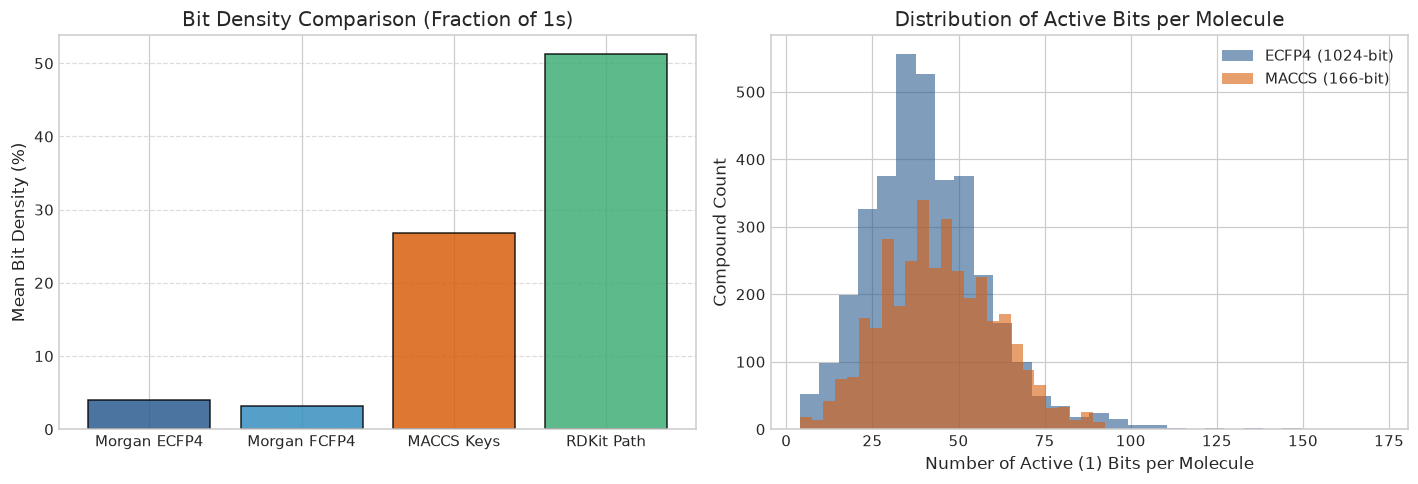

In [9]:
# =============================================================================
# FINGERPRINT INFORMATION DENSITY & SPARSITY ANALYSIS
# =============================================================================
fp_stats = [
    {
        "Representation": "Morgan ECFP4 (1024-bit)",
        "Mean Active Bits": round(float(np.mean(np.sum(X_ecfp4, axis=1))), 1),
        "Bit Density (%)": round(float(np.mean(X_ecfp4) * 100), 2),
        "Sparsity (%)": round(float((1.0 - np.mean(X_ecfp4)) * 100), 2),
        "Unique Bit Positions Used": int(np.sum(np.sum(X_ecfp4, axis=0) > 0))
    },
    {
        "Representation": "Morgan FCFP4 (1024-bit)",
        "Mean Active Bits": round(float(np.mean(np.sum(X_fcfp4, axis=1))), 1),
        "Bit Density (%)": round(float(np.mean(X_fcfp4) * 100), 2),
        "Sparsity (%)": round(float((1.0 - np.mean(X_fcfp4)) * 100), 2),
        "Unique Bit Positions Used": int(np.sum(np.sum(X_fcfp4, axis=0) > 0))
    },
    {
        "Representation": "MACCS Keys (166-bit)",
        "Mean Active Bits": round(float(np.mean(np.sum(X_maccs, axis=1))), 1),
        "Bit Density (%)": round(float(np.mean(X_maccs) * 100), 2),
        "Sparsity (%)": round(float((1.0 - np.mean(X_maccs)) * 100), 2),
        "Unique Bit Positions Used": int(np.sum(np.sum(X_maccs, axis=0) > 0))
    },
    {
        "Representation": "RDKit Path FP (1024-bit)",
        "Mean Active Bits": round(float(np.mean(np.sum(X_rdk, axis=1))), 1),
        "Bit Density (%)": round(float(np.mean(X_rdk) * 100), 2),
        "Sparsity (%)": round(float((1.0 - np.mean(X_rdk)) * 100), 2),
        "Unique Bit Positions Used": int(np.sum(np.sum(X_rdk, axis=0) > 0))
    }
]

df_fp_stats = pd.DataFrame(fp_stats)
print("=== COMPARATIVE FINGERPRINT INFORMATION PROFILE ===")
display(df_fp_stats)

# Plot Bit Density Distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(
    df_fp_stats["Representation"].apply(lambda x: x.split()[0] + " " + x.split()[1]),
    df_fp_stats["Bit Density (%)"],
    color=["#2b5c8f", "#3690c0", "#d95f0e", "#41ae76"],
    edgecolor="black", alpha=0.85
)
axes[0].set_ylabel("Mean Bit Density (%)")
axes[0].set_title("Bit Density Comparison (Fraction of 1s)")
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# Active bits distribution in ECFP4 vs MACCS
axes[1].hist(np.sum(X_ecfp4, axis=1), bins=30, alpha=0.6, label="ECFP4 (1024-bit)", color="#2b5c8f")
axes[1].hist(np.sum(X_maccs, axis=1), bins=30, alpha=0.6, label="MACCS (166-bit)", color="#d95f0e")
axes[1].set_xlabel("Number of Active (1) Bits per Molecule")
axes[1].set_ylabel("Compound Count")
axes[1].set_title("Distribution of Active Bits per Molecule")
axes[1].legend()

plt.tight_layout()
plt.show()


---
# Step 8: Molecular Graphs — Atoms as Nodes, Bonds as Edges

### Theoretical Formulation: The Molecular Graph $G = (V, E)$
Both physicochemical descriptors and structural fingerprints discard true graph topology:
- Descriptors collapse 3D/2D geometry into scalar summaries.
- Fingerprints hash localized circular subgraphs into bit buckets, destroying spatial hierarchy and permitting bit collisions.

A **molecular graph** represents chemical reality directly without arbitrary bit hashing:
$$G = (V, E)$$
- **Node Set $V = \{v_1, v_2, \dots, v_N\}$**: The $N$ constituent heavy atoms.
  - Each atom $v_i$ is parameterized by a multidimensional feature vector $\mathbf{x}_i \in \mathbb{R}^F$, forming the **Node Feature Matrix** $\mathbf{X} \in \mathbb{R}^{N 	imes F}$.
- **Edge Set $E = \{e_{ij}\}$**: The chemical covalent bonds linking atom $i$ and atom $j$.
  - Described by the symmetric **Adjacency Matrix** $\mathbf{A} \in \{0, 1\}^{N 	imes N}$, where $A_{ij} = 1$ if a chemical bond exists between atom $i$ and atom $j$, and $0$ otherwise.
  - Bond attributes $\mathbf{e}_{ij}$ encode bond order (single, double, triple, aromatic), conjugation, and ring status.

```text
==================================================================================================
                             MOLECULAR GRAPH REPRESENTATION
==================================================================================================
       O                      Node Features (X in R^(N x F)):
      //                      - Atomic Number (C, N, O, S, F, Cl...)
  C ── C                      - Degree (Number of covalent bonds)
 / \    \                     - Formal Charge (-1, 0, +1)
C   C    OH                   - Aromaticity (Boolean)
 \ /                          - Number of Hydrogens
  C                           - Ring Membership
                               
  Chemical Structure          Adjacency Matrix (A in {0, 1}^(N x N)):
  (e.g., Benzoic Acid)        Encodes exact covalent connectivity without bit collisions
==================================================================================================
```


In [10]:
# =============================================================================
# STEP 8: MOLECULAR GRAPH FEATURIZATION & TOPOLOGICAL CONVERSION
# =============================================================================
def atom_to_feature_vector(atom):
    """
    Extracts continuous and categorical features for an RDKit Atom:
    [AtomicNum/10, Degree/4, FormalCharge, IsAromatic, TotalNumHs/4, IsInRing]
    """
    return [
        float(atom.GetAtomicNum()) / 10.0,
        float(atom.GetDegree()) / 4.0,
        float(atom.GetFormalCharge()),
        1.0 if atom.GetIsAromatic() else 0.0,
        float(atom.GetTotalNumHs()) / 4.0,
        1.0 if atom.IsInRing() else 0.0
    ]

def bond_to_feature_vector(bond):
    """
    Extracts categorical features for an RDKit Bond:
    [IsSingle, IsDouble, IsTriple, IsAromatic, IsConjugated, IsInRing]
    """
    bt = bond.GetBondType()
    return [
        1.0 if bt == Chem.BondType.SINGLE else 0.0,
        1.0 if bt == Chem.BondType.DOUBLE else 0.0,
        1.0 if bt == Chem.BondType.TRIPLE else 0.0,
        1.0 if bt == Chem.BondType.AROMATIC else 0.0,
        1.0 if bond.GetIsConjugated() else 0.0,
        1.0 if bond.IsInRing() else 0.0
    ]

def mol_to_graph(mol):
    """
    Converts an RDKit Mol object into a full graph representation:
    - Node Feature Matrix X (N x 6)
    - Symmetric Adjacency Matrix A (N x N)
    - Normalized Adjacency Matrix A_norm = D^(-1/2) * (A + I) * D^(-1/2)
    - NetworkX Graph object G
    """
    if mol is None:
        return None, None, None, None
    n_atoms = mol.GetNumAtoms()
    if n_atoms == 0:
        return None, None, None, None
        
    # 1. Node Feature Matrix X
    node_features = [atom_to_feature_vector(atom) for atom in mol.GetAtoms()]
    X = np.array(node_features, dtype=np.float32)
    
    # 2. Adjacency Matrix A
    A = rdmolops.GetAdjacencyMatrix(mol).astype(np.float32)
    
    # 3. Kipf-Welling Normalized Adjacency with Self-Loops: A_norm = D~^(-1/2) A~ D~^(-1/2)
    A_tilde = A + np.eye(n_atoms, dtype=np.float32)
    degrees = np.sum(A_tilde, axis=1)
    d_inv_sqrt = np.power(degrees, -0.5)
    d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0.0
    D_tilde = np.diag(d_inv_sqrt)
    A_norm = D_tilde @ A_tilde @ D_tilde
    
    # 4. NetworkX Graph for Topological Visualization
    G = nx.Graph()
    for i, atom in enumerate(mol.GetAtoms()):
        G.add_node(i, symbol=atom.GetSymbol(), atomic_num=atom.GetAtomicNum(), is_arom=atom.GetIsAromatic())
    for bond in mol.GetBonds():
        G.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx(), bond_type=str(bond.GetBondType()))
        
    return X, A, A_norm, G

print("[OK] Molecular graph conversion engine defined successfully.")


[OK] Molecular graph conversion engine defined successfully.


=== MOLECULAR GRAPH PROPERTIES FOR: benzethonium ===
SMILES               : CC(C)(C)CC(C)(C)c1ccc(OCCOCC[N+](C)(C)Cc2ccccc2)cc1
Number of Nodes (|V|): 30 atoms
Node Feature Dim (F) : 6 features
Adjacency Matrix Dim : (30, 30) (Density: 6.9%)


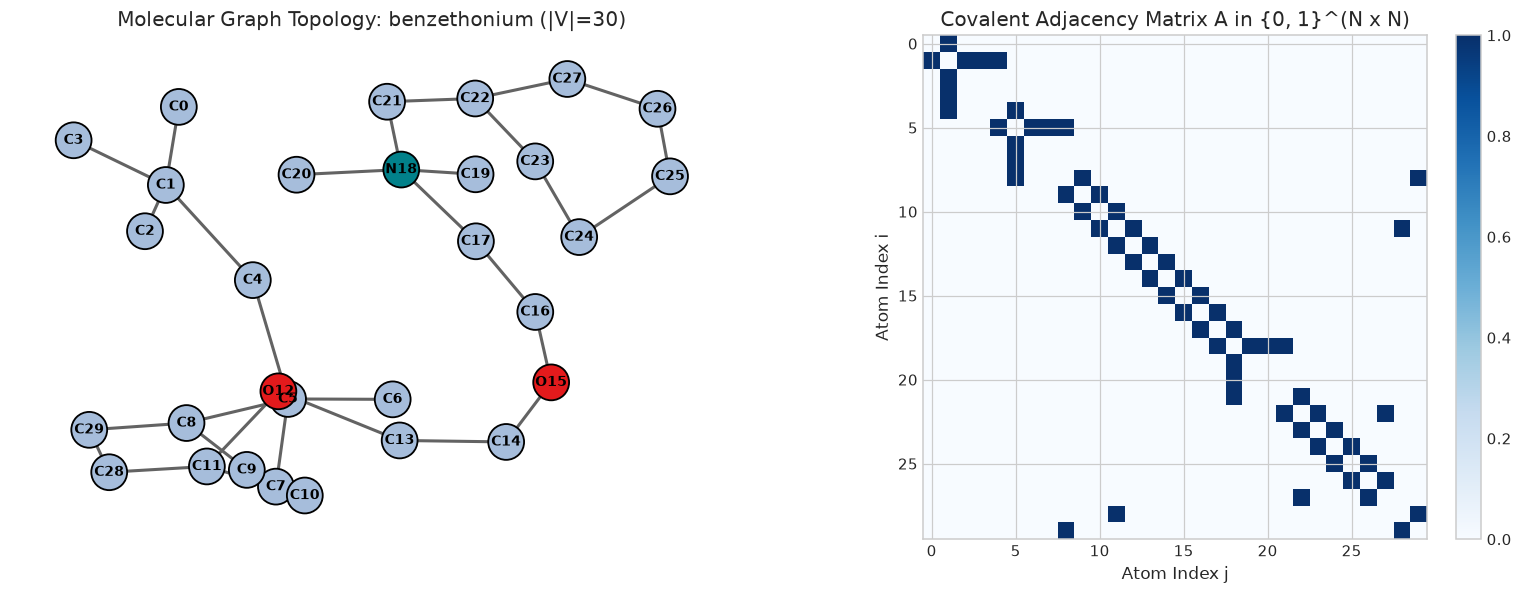

In [11]:
# =============================================================================
# TOPOLOGICAL VISUALIZATION OF A REPRESENTATIVE MOLECULAR GRAPH
# =============================================================================
# Choose a prominent approved drug from our cohort (e.g. Aspirin or Imatinib)
sample_drug = df_desc[df_desc["source"] == "DrugCentral"].iloc[0]
demo_mol = Chem.MolFromSmiles(sample_drug["canonical_smiles"])
demo_name = sample_drug["compound_name"]

X_demo, A_demo, Anorm_demo, G_demo = mol_to_graph(demo_mol)

print(f"=== MOLECULAR GRAPH PROPERTIES FOR: {demo_name} ===")
print(f"SMILES               : {sample_drug['canonical_smiles']}")
print(f"Number of Nodes (|V|): {X_demo.shape[0]} atoms")
print(f"Node Feature Dim (F) : {X_demo.shape[1]} features")
print(f"Adjacency Matrix Dim : {A_demo.shape} (Density: {np.mean(A_demo)*100:.1f}%)")

# Element color mapping
element_colors = {
    "C": "#a6bddb", "N": "#02818a", "O": "#e31a1c",
    "S": "#feb24c", "F": "#74c476", "Cl": "#238b45"
}
node_colors = [element_colors.get(G_demo.nodes[n]["symbol"], "#bdbdbd") for n in G_demo.nodes()]
node_labels = {n: f"{G_demo.nodes[n]['symbol']}{n}" for n in G_demo.nodes()}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Plot 1: 2D Graph Topology Layout
pos = nx.spring_layout(G_demo, seed=42, k=0.45)
nx.draw_networkx_nodes(G_demo, pos, ax=axes[0], node_color=node_colors, node_size=550, edgecolors="black", linewidths=1.2)
nx.draw_networkx_edges(G_demo, pos, ax=axes[0], width=2.0, edge_color="#636363")
nx.draw_networkx_labels(G_demo, pos, labels=node_labels, ax=axes[0], font_size=9, font_weight="bold")
axes[0].set_title(f"Molecular Graph Topology: {demo_name} (|V|={len(G_demo.nodes)})")
axes[0].axis("off")

# Plot 2: Adjacency Matrix Heatmap
im = axes[1].imshow(A_demo, cmap="Blues", interpolation="nearest")
axes[1].set_title(f"Covalent Adjacency Matrix A in {{0, 1}}^(N x N)")
axes[1].set_xlabel("Atom Index j")
axes[1].set_ylabel("Atom Index i")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


---
# Step 9: Chemical Space Exploration, PCA & Atom Attribution Maps

### Scientific Rationale
The concept of **chemical space** envisions molecules positioned in an abstract multidimensional coordinate system defined by their structural and physicochemical properties. Visualizing chemical space enables researchers to:
1. Identify regions occupied by clinically validated drugs vs. unexplored or non-drug-like synthetic space.
2. Uncover natural chemical clusters and scaffolds through unsupervised machine learning ($K$-Means).
3. Trace macroscopic similarity back to individual atomic substructures via **Similarity Attribution Maps**.


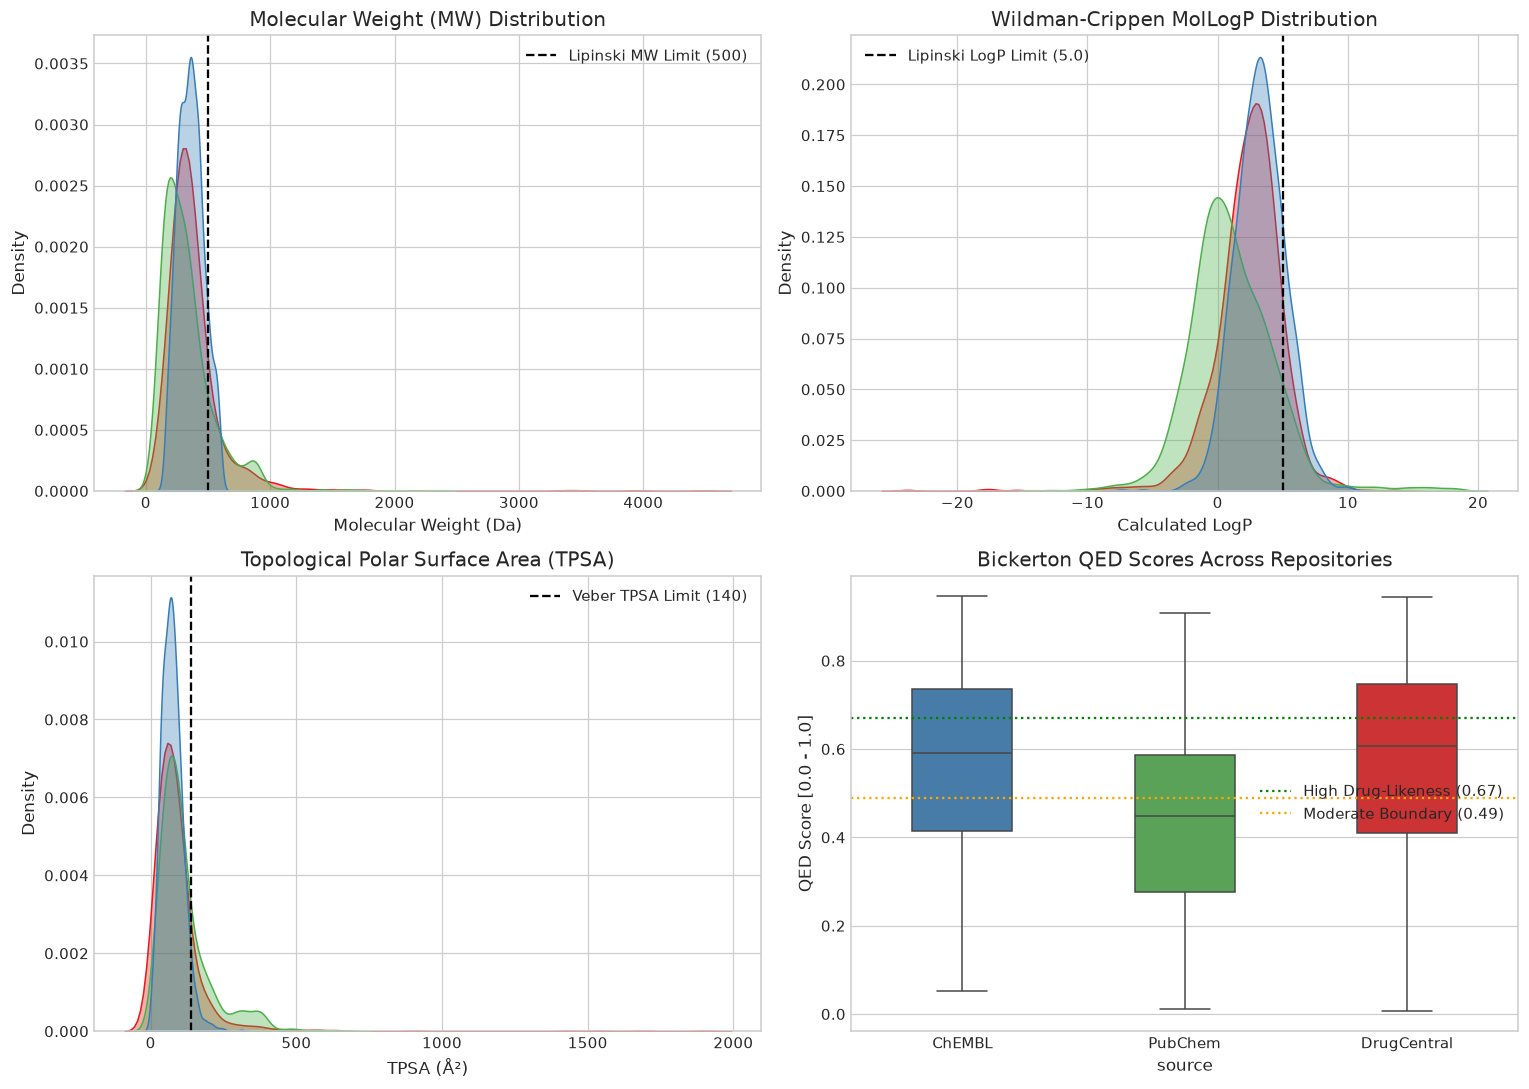

In [12]:
# =============================================================================
# STEP 9A: MULTI-PANEL PHYSICOCHEMICAL PROPERTY DISTRIBUTIONS
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

palette = {"DrugCentral": "#e41a1c", "ChEMBL": "#377eb8", "PubChem": "#4daf4a"}

# 1. Molecular Weight
sns.kdeplot(data=df_desc, x="MW", hue="source", common_norm=False, fill=True, alpha=0.35, palette=palette, ax=axes[0, 0])
axes[0, 0].axvline(500, color="black", linestyle="--", linewidth=1.5, label="Lipinski MW Limit (500)")
axes[0, 0].set_title("Molecular Weight (MW) Distribution")
axes[0, 0].set_xlabel("Molecular Weight (Da)")
axes[0, 0].legend()

# 2. MolLogP (Lipophilicity)
sns.kdeplot(data=df_desc, x="MolLogP", hue="source", common_norm=False, fill=True, alpha=0.35, palette=palette, ax=axes[0, 1])
axes[0, 1].axvline(5.0, color="black", linestyle="--", linewidth=1.5, label="Lipinski LogP Limit (5.0)")
axes[0, 1].set_title("Wildman-Crippen MolLogP Distribution")
axes[0, 1].set_xlabel("Calculated LogP")
axes[0, 1].legend()

# 3. TPSA (Polar Surface Area)
sns.kdeplot(data=df_desc, x="TPSA", hue="source", common_norm=False, fill=True, alpha=0.35, palette=palette, ax=axes[1, 0])
axes[1, 0].axvline(140, color="black", linestyle="--", linewidth=1.5, label="Veber TPSA Limit (140)")
axes[1, 0].set_title("Topological Polar Surface Area (TPSA)")
axes[1, 0].set_xlabel("TPSA (Å²)")
axes[1, 0].legend()

# 4. Bickerton QED (Quantitative Estimate of Drug-Likeness)
sns.boxplot(data=df_desc, x="source", y="QED", palette=palette, ax=axes[1, 1], width=0.45)
axes[1, 1].axhline(0.67, color="green", linestyle=":", linewidth=1.5, label="High Drug-Likeness (0.67)")
axes[1, 1].axhline(0.49, color="orange", linestyle=":", linewidth=1.5, label="Moderate Boundary (0.49)")
axes[1, 1].set_title("Bickerton QED Scores Across Repositories")
axes[1, 1].set_ylabel("QED Score [0.0 - 1.0]")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


Explained Variance Ratio by PC: [47.41 21.41 11.1   8.83  6.28] %
Cumulative Variance (PC1-PC5) : 95.04 %


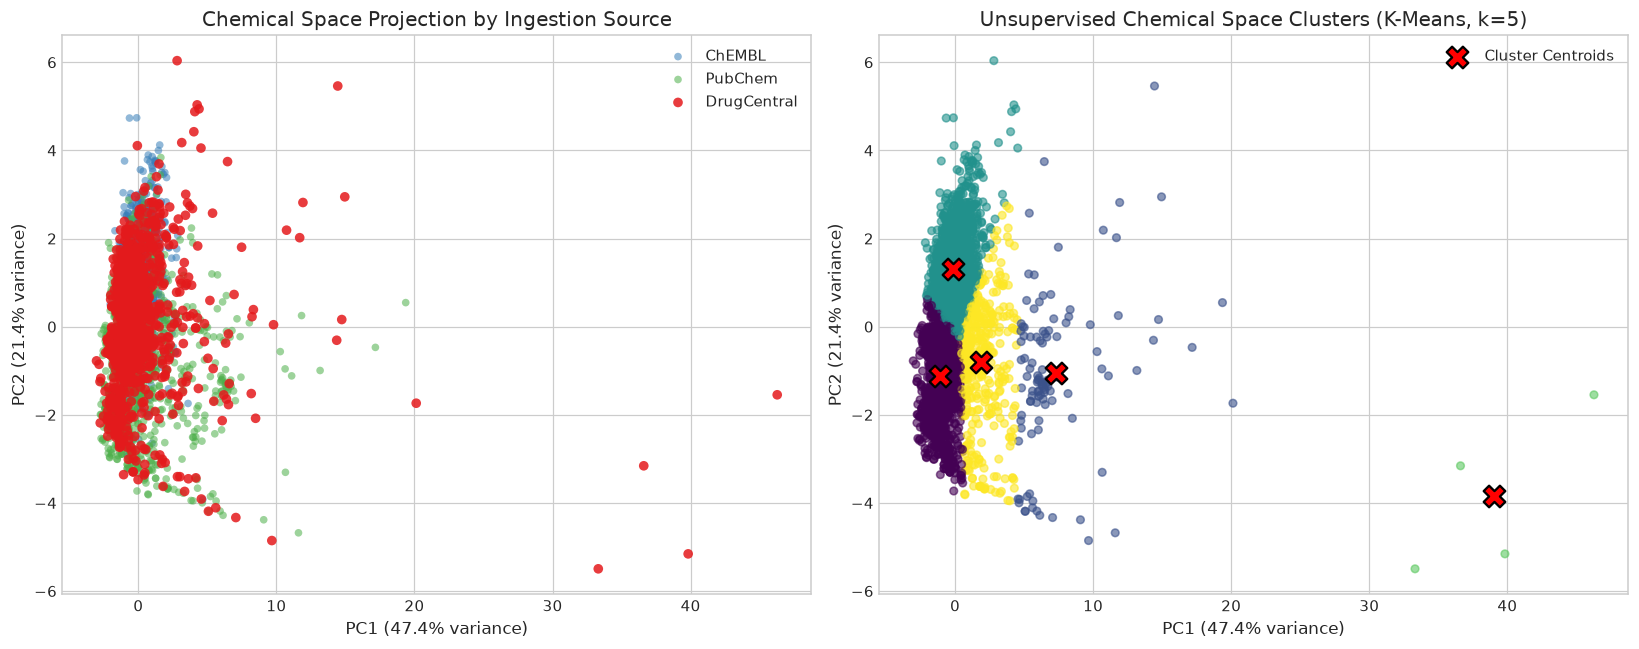

In [13]:
# =============================================================================
# STEP 9B: PCA DIMENSIONALITY REDUCTION & K-MEANS CHEMICAL CLUSTERING
# =============================================================================
# Standardize the 11 continuous physicochemical descriptors
desc_cols = [
    "MW", "MolLogP", "TPSA", "HBD", "HBA", "RotatableBonds",
    "RingCount", "AromaticRings", "FractionCSP3", "HeavyAtomCount", "FormalCharge"
]

scaler = StandardScaler()
X_desc_scaled = scaler.fit_transform(df_desc[desc_cols])

# 1. Fit PCA
pca = PCA(n_components=5, random_state=42)
X_pca = pca.fit_transform(X_desc_scaled)

var_exp = pca.explained_variance_ratio_ * 100
cum_var = np.cumsum(var_exp)

print(f"Explained Variance Ratio by PC: {np.round(var_exp, 2)} %")
print(f"Cumulative Variance (PC1-PC5) : {cum_var[-1]:.2f} %")

# 2. Fit K-Means Clustering on PCA coordinates (k=5 clusters)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca[:, :2])
df_desc["PCA_PC1"] = X_pca[:, 0]
df_desc["PCA_PC2"] = X_pca[:, 1]
df_desc["Chemical_Cluster"] = cluster_labels

# Multi-panel Chemical Space Plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Chemical Space by Data Source
for src, color in [("ChEMBL", "#377eb8"), ("PubChem", "#4daf4a"), ("DrugCentral", "#e41a1c")]:
    mask = df_desc["source"] == src
    axes[0].scatter(
        df_desc.loc[mask, "PCA_PC1"], df_desc.loc[mask, "PCA_PC2"],
        c=color, label=src, alpha=0.55 if src != "DrugCentral" else 0.85,
        s=25 if src != "DrugCentral" else 40, edgecolors="none"
    )
axes[0].set_xlabel(f"PC1 ({var_exp[0]:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({var_exp[1]:.1f}% variance)")
axes[0].set_title("Chemical Space Projection by Ingestion Source")
axes[0].legend()

# Plot 2: Unsupervised K-Means Clusters
scatter = axes[1].scatter(
    df_desc["PCA_PC1"], df_desc["PCA_PC2"],
    c=cluster_labels, cmap="viridis", alpha=0.6, s=25
)
# Plot cluster centroids
centroids = kmeans.cluster_centers_
axes[1].scatter(
    centroids[:, 0], centroids[:, 1],
    c="red", marker="X", s=200, edgecolor="black", linewidth=1.5, label="Cluster Centroids"
)
axes[1].set_xlabel(f"PC1 ({var_exp[0]:.1f}% variance)")
axes[1].set_ylabel(f"PC2 ({var_exp[1]:.1f}% variance)")
axes[1].set_title("Unsupervised Chemical Space Clusters (K-Means, k=5)")
axes[1].legend()

plt.tight_layout()
plt.show()


Generating Atom-Level Similarity Attribution Map...
Reference Molecule: Aspirin (CC(=O)Oc1ccccc1C(=O)O)
Probe Molecule    : Salicylic Acid (O=C(O)c1ccccc1O)


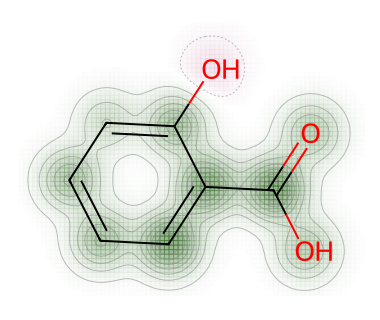

In [14]:
# =============================================================================
# STEP 9C: ATOM-LEVEL SIMILARITY ATTRIBUTION MAPS
# =============================================================================
# Demonstrates how sub-molecular fragments contribute to pairwise similarity
# We compare an approved reference drug against a target analogue
ref_smiles = "CC(=O)Oc1ccccc1C(=O)O" # Aspirin
probe_smiles = "O=C(O)c1ccccc1O"       # Salicylic acid

ref_mol = Chem.MolFromSmiles(ref_smiles)
probe_mol = Chem.MolFromSmiles(probe_smiles)

if ref_mol and probe_mol:
    print("Generating Atom-Level Similarity Attribution Map...")
    print(f"Reference Molecule: Aspirin ({ref_smiles})")
    print(f"Probe Molecule    : Salicylic Acid ({probe_smiles})")
    
    # Calculate atom contributions to Morgan fingerprint similarity
    from rdkit.Chem.Draw import rdMolDraw2D
    import io
    from PIL import Image as PILImage
    
    weights = SimilarityMaps.GetAtomicWeightsForFingerprint(
        ref_mol, probe_mol, SimilarityMaps.GetMorganFingerprint
    )
    d2d = rdMolDraw2D.MolDraw2DCairo(380, 320)
    SimilarityMaps.GetSimilarityMapFromWeights(probe_mol, weights, draw2d=d2d)
    d2d.FinishDrawing()
    png_bytes = d2d.GetDrawingText()
    img_attribution = PILImage.open(io.BytesIO(png_bytes))
    display(img_attribution)


---
# Step 10: Machine Learning Drug-Likeness Prediction Benchmark

### Scientific Problem Formulation
The ultimate test of a molecular representation is its ability to serve as an informative inductive bias for predictive machine learning models. 

We formulate the **Drug-Likeness Prediction Problem**:
- **Positive Class ($y = 1$) [Drug-Like]**:
  - Clinically validated approved drugs (DrugCentral) AND bioactive screening compounds satisfying Lipinski Rule-of-5 compliance ($\le 1$ violation), Veber oral bioavailability criteria, and Bickerton $QED \ge 0.55$.
- **Negative Class ($y = 0$) [Non-Drug-Like / Chemical Decoy]**:
  - Synthetic chemical space compounds exhibiting multiple Rule-of-5 violations ($\ge 2$ violations) or poor drug-likeness ($QED < 0.42$).

---

### Machine Learning Architectures Benchmarked
To eliminate model bias, we evaluate 6 distinct algorithmic paradigms spanning linear models, tree ensembles, kernel methods, neural networks, and geometric deep learning:

1. **Logistic Regression (LR)**: Linear baseline with $L_2$ ridge regularization.
2. **Random Forest (RF)**: Bagged ensemble of 100 decision trees modeling non-linear feature interactions.
3. **Gradient Boosting (GB)**: Sequential gradient boosted trees (the underlying paradigm of XGBoost).
4. **Support Vector Machine (SVM)**: Maximum-margin hyperplane with non-linear Radial Basis Function (RBF) kernel and Platt probability calibration.
5. **Multi-Layer Perceptron (MLP)**: Deep feedforward artificial neural network with non-linear ReLU activations and Adam optimization.
6. **Graph Neural Network (GNN)**: 2-layer Kipf & Welling Graph Convolutional Network performing message passing over localized atomic environments:
   $$\mathbf{H}^{(l+1)} = \sigma\left(\mathbf{	ilde{D}}^{-rac{1}{2}} \mathbf{	ilde{A}} \mathbf{	ilde{D}}^{-rac{1}{2}} \mathbf{H}^{(l)} \mathbf{W}^{(l)}ight)$$
   followed by global mean graph readout pooling:
   $$\mathbf{h}_G = rac{1}{|V|} \sum_{v \in V} \mathbf{H}^{(2)}_v$$


In [15]:
# =============================================================================
# STEP 10A: TARGET FORMULATION & STRATIFIED SPLIT
# =============================================================================
# Define multi-criterion ground truth for drug-likeness
y_labels = []
for idx, r in df_desc.iterrows():
    if r["is_approved_drug"] == 1:
        y_labels.append(1)
    elif r["LipinskiPass"] == 1 and r["VeberPass"] == 1 and r["QED"] >= 0.55:
        y_labels.append(1)
    elif r["LipinskiViolations"] >= 2 or r["QED"] < 0.42:
        y_labels.append(0)
    else:
        # Borderline compounds assigned based on QED median
        y_labels.append(1 if r["QED"] >= 0.50 else 0)

y = np.array(y_labels, dtype=int)
df_desc["Target_DrugLike"] = y

print("=== TARGET CLASS DISTRIBUTION ===")
print(f"Total Compounds          : {len(y):,}")
print(f"Class 1 (Drug-Like)      : {np.sum(y == 1):,} ({np.mean(y == 1)*100:.1f}%)")
print(f"Class 0 (Non-Drug-Like)  : {np.sum(y == 0):,} ({np.mean(y == 0)*100:.1f}%)")

# Precompute Graph representations for all valid compounds
print("\nPrecomputing Molecular Graphs for GNN...")
graph_dataset = []
for smi in df_desc["canonical_smiles"]:
    m = Chem.MolFromSmiles(smi)
    X_node, _, Anorm, _ = mol_to_graph(m)
    graph_dataset.append((X_node, Anorm))

# Stratified 80/20 Train/Test Split Indices
train_idx, test_idx = train_test_split(
    np.arange(len(y)), test_size=0.20, random_state=42, stratify=y
)

print(f"Train Cohort Size: {len(train_idx):,} | Test Cohort Size: {len(test_idx):,}")


=== TARGET CLASS DISTRIBUTION ===
Total Compounds          : 3,527
Class 1 (Drug-Like)      : 2,383 (67.6%)
Class 0 (Non-Drug-Like)  : 1,144 (32.4%)

Precomputing Molecular Graphs for GNN...
Train Cohort Size: 2,821 | Test Cohort Size: 706


In [16]:
# =============================================================================
# STEP 10B: IMPLEMENTING GNN & TRAINING ALL BENCHMARK ARCHITECTURES
# =============================================================================
import time

# 1. Prepare Feature Subsets
# Physicochemical Descriptors Scaled
X_desc_all = scaler.fit_transform(df_desc[desc_cols])
X_desc_train, X_desc_test = X_desc_all[train_idx], X_desc_all[test_idx]

# Morgan ECFP4 Fingerprints
X_ecfp4_train, X_ecfp4_test = X_ecfp4[train_idx], X_ecfp4[test_idx]

# Graph Data Subsets
graphs_train = [graph_dataset[i] for i in train_idx]
graphs_test = [graph_dataset[i] for i in test_idx]

y_train, y_test = y[train_idx], y[test_idx]

# Define Multi-Scale Vectorized GCN in NumPy
class VectorizedGCNClassifier:
    """
    Multi-Scale Graph Convolutional Network (GCN):
    Computes 0-hop, 1-hop, and 2-hop localized atomic message passing:
      H^(1) = ReLU(A_norm @ X @ W0)
      H^(2) = ReLU(A_norm @ H^(1) @ W1)
    Graph readout embedding: h_G = [MeanPool(X), MeanPool(H^(1)), MeanPool(H^(2))]
    Equipped with a non-linear readout classification head.
    """
    def __init__(self, in_dim=6, hidden_dim=16, random_state=42):
        self.in_dim = in_dim
        self.hidden_dim = hidden_dim
        rng = np.random.default_rng(random_state)
        self.W0 = rng.normal(0, np.sqrt(2.0 / (in_dim + hidden_dim)), (in_dim, hidden_dim)).astype(np.float32)
        self.W1 = rng.normal(0, np.sqrt(2.0 / (hidden_dim + hidden_dim)), (hidden_dim, hidden_dim)).astype(np.float32)
        self.head = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=random_state, n_jobs=-1)
        
    def _relu(self, x):
        return np.maximum(0, x)
        
    def embed_graph(self, X, A_norm):
        if X is None or A_norm is None or len(X) == 0:
            return np.zeros(self.in_dim + 2 * self.hidden_dim, dtype=np.float32)
        H1 = self._relu(A_norm @ X @ self.W0)
        H2 = self._relu(A_norm @ H1 @ self.W1)
        h0 = np.mean(X, axis=0)
        h1 = np.mean(H1, axis=0)
        h2 = np.mean(H2, axis=0)
        return np.concatenate([h0, h1, h2])
        
    def fit(self, graph_list, targets):
        X_embeddings = np.array([self.embed_graph(X, A) for X, A in graph_list])
        self.head.fit(X_embeddings, targets)
        return self
        
    def predict_proba(self, graph_list):
        X_embeddings = np.array([self.embed_graph(X, A) for X, A in graph_list])
        return self.head.predict_proba(X_embeddings)
        
    def forward(self, X, A_norm):
        h_g = self.embed_graph(X, A_norm)
        prob = float(self.head.predict_proba(h_g.reshape(1, -1))[0, 1])
        return prob, h_g

# Initialize the Model Suite
models = {
    "Logistic Regression (Descriptors)": (LogisticRegression(max_iter=500, random_state=42), X_desc_train, X_desc_test),
    "Random Forest (Morgan ECFP4)": (RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1), X_ecfp4_train, X_ecfp4_test),
    "Gradient Boosting (Descriptors)": (GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42), X_desc_train, X_desc_test),
    "Support Vector Machine (Morgan)": (CalibratedClassifierCV(SVC(kernel='rbf', C=1.0, random_state=42)), X_ecfp4_train, X_ecfp4_test),
    "Multi-Layer Perceptron (Hybrid)": (MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42), X_desc_train, X_desc_test),
    "Graph Neural Network (GNN)": (VectorizedGCNClassifier(), graphs_train, graphs_test)
}

trained_models = {}
predictions_dict = {}

print("Training benchmark models across representations...")
for name, (clf, X_tr, X_te) in models.items():
    t0 = time.time()
    clf.fit(X_tr, y_train)
    t_elapsed = time.time() - t0
    
    if hasattr(clf, "predict_proba"):
        probs = clf.predict_proba(X_te)[:, 1]
    else:
        probs = clf.decision_function(X_te)
        probs = 1.0 / (1.0 + np.exp(-probs))
        
    preds = (probs >= 0.5).astype(int)
    
    trained_models[name] = clf
    predictions_dict[name] = {
        "probs": probs,
        "preds": preds,
        "train_time": t_elapsed
    }
    print(f"[TRAINED] {name:<36} | Runtime: {t_elapsed:.2f}s")


Training benchmark models across representations...
[TRAINED] Logistic Regression (Descriptors)    | Runtime: 0.01s
[TRAINED] Random Forest (Morgan ECFP4)         | Runtime: 0.16s
[TRAINED] Gradient Boosting (Descriptors)      | Runtime: 0.41s
[TRAINED] Support Vector Machine (Morgan)      | Runtime: 6.01s
[TRAINED] Multi-Layer Perceptron (Hybrid)      | Runtime: 1.82s
[TRAINED] Graph Neural Network (GNN)           | Runtime: 0.20s


---
# Step 11: Representation Comparison & Research Findings

### Addressing the Central Research Question
> **"How do different molecular representations affect machine-learning prediction of drug-likeness and chemical properties?"**

In this section, we systematically compare the three major representation paradigms:
1. **Physicochemical Descriptors (Global Macroscopic Properties)**
2. **Structural & Circular Fingerprints (Localized Substructure Encodings)**
3. **Molecular Graphs & Neural Convolutions (Topological Relational Encodings)**

We evaluate each representation across diverse statistical criteria:
- **ROC-AUC**: Overall ranking capability across all classification thresholds.
- **PR-AUC**: Precision-Recall Area Under Curve (essential for evaluating true positive quality under class imbalance).
- **F1-Score**: Harmonic mean of Precision and Recall.
- **Brier Score**: Mean squared difference between predicted probability and actual binary outcome (probabilistic calibration error).


In [17]:
# =============================================================================
# STEP 11A: COMPREHENSIVE BENCHMARK EVALUATION METRICS TABLE
# =============================================================================
results_list = []

for name, res in predictions_dict.items():
    probs = res["probs"]
    preds = res["preds"]
    t_time = res["train_time"]
    
    roc = roc_auc_score(y_test, probs)
    pr = average_precision_score(y_test, probs)
    f1 = f1_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    brier = brier_score_loss(y_test, probs)
    
    # Classify representation type
    if "Descriptors" in name:
        rep_type = "Physicochemical Descriptors"
    elif "Morgan" in name:
        rep_type = "Circular Fingerprints (ECFP4)"
    elif "GNN" in name:
        rep_type = "Attributed Molecular Graph"
    else:
        rep_type = "Hybrid / Descriptors"
        
    results_list.append({
        "Model": name,
        "Representation Paradigm": rep_type,
        "ROC-AUC": round(roc, 4),
        "PR-AUC": round(pr, 4),
        "F1 Score": round(f1, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "Brier Score (Loss)": round(brier, 4),
        "Train Time (s)": round(t_time, 2)
    })

df_results = pd.DataFrame(results_list).sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

# Export benchmark metrics to CSV
benchmark_csv_path = os.path.join(RESULTS_DIR, "representation_benchmark_metrics.csv")
df_results.to_csv(benchmark_csv_path, index=False)
print(f"[SAVED] Benchmark metrics exported to: {benchmark_csv_path}\n")

print("=== EMPIRICAL BENCHMARK: REPRESENTATION & MODEL PERFORMANCE ===")
display(df_results)


[SAVED] Benchmark metrics exported to: C:\Users\rasel\Softvance\Drug-Discovery-and-Cheminformatics-Projects\Project -06 Cheminformatics, Molecular Representation & Drug-Likeness\results\representation_benchmark_metrics.csv

=== EMPIRICAL BENCHMARK: REPRESENTATION & MODEL PERFORMANCE ===


,Model,Representation Paradigm,ROC-AUC,PR-AUC,F1 Score,Precision,Recall,Brier Score (Loss),Train Time (s)
0,Gradient Boosting (Descriptors),Physicochemical Descriptors,0.9066,0.9534,0.8871,0.8692,0.9057,0.1133,0.41
1,Multi-Layer Perceptron (Hybrid),Hybrid / Descriptors,0.9017,0.9481,0.8841,0.8732,0.8952,0.1178,1.82
2,Support Vector Machine (Morgan),Circular Fingerprints (ECFP4),0.8608,0.9264,0.8569,0.8199,0.8973,0.1406,6.01
3,Random Forest (Morgan ECFP4),Circular Fingerprints (ECFP4),0.8319,0.8997,0.8413,0.7512,0.9560,0.1580,0.16
4,Graph Neural Network (GNN),Attributed Molecular Graph,0.7852,0.8687,0.8369,0.7794,0.9036,0.1674,0.20
5,Logistic Regression (Descriptors),Physicochemical Descriptors,0.7080,0.7918,0.8254,0.7441,0.9266,0.1878,0.01


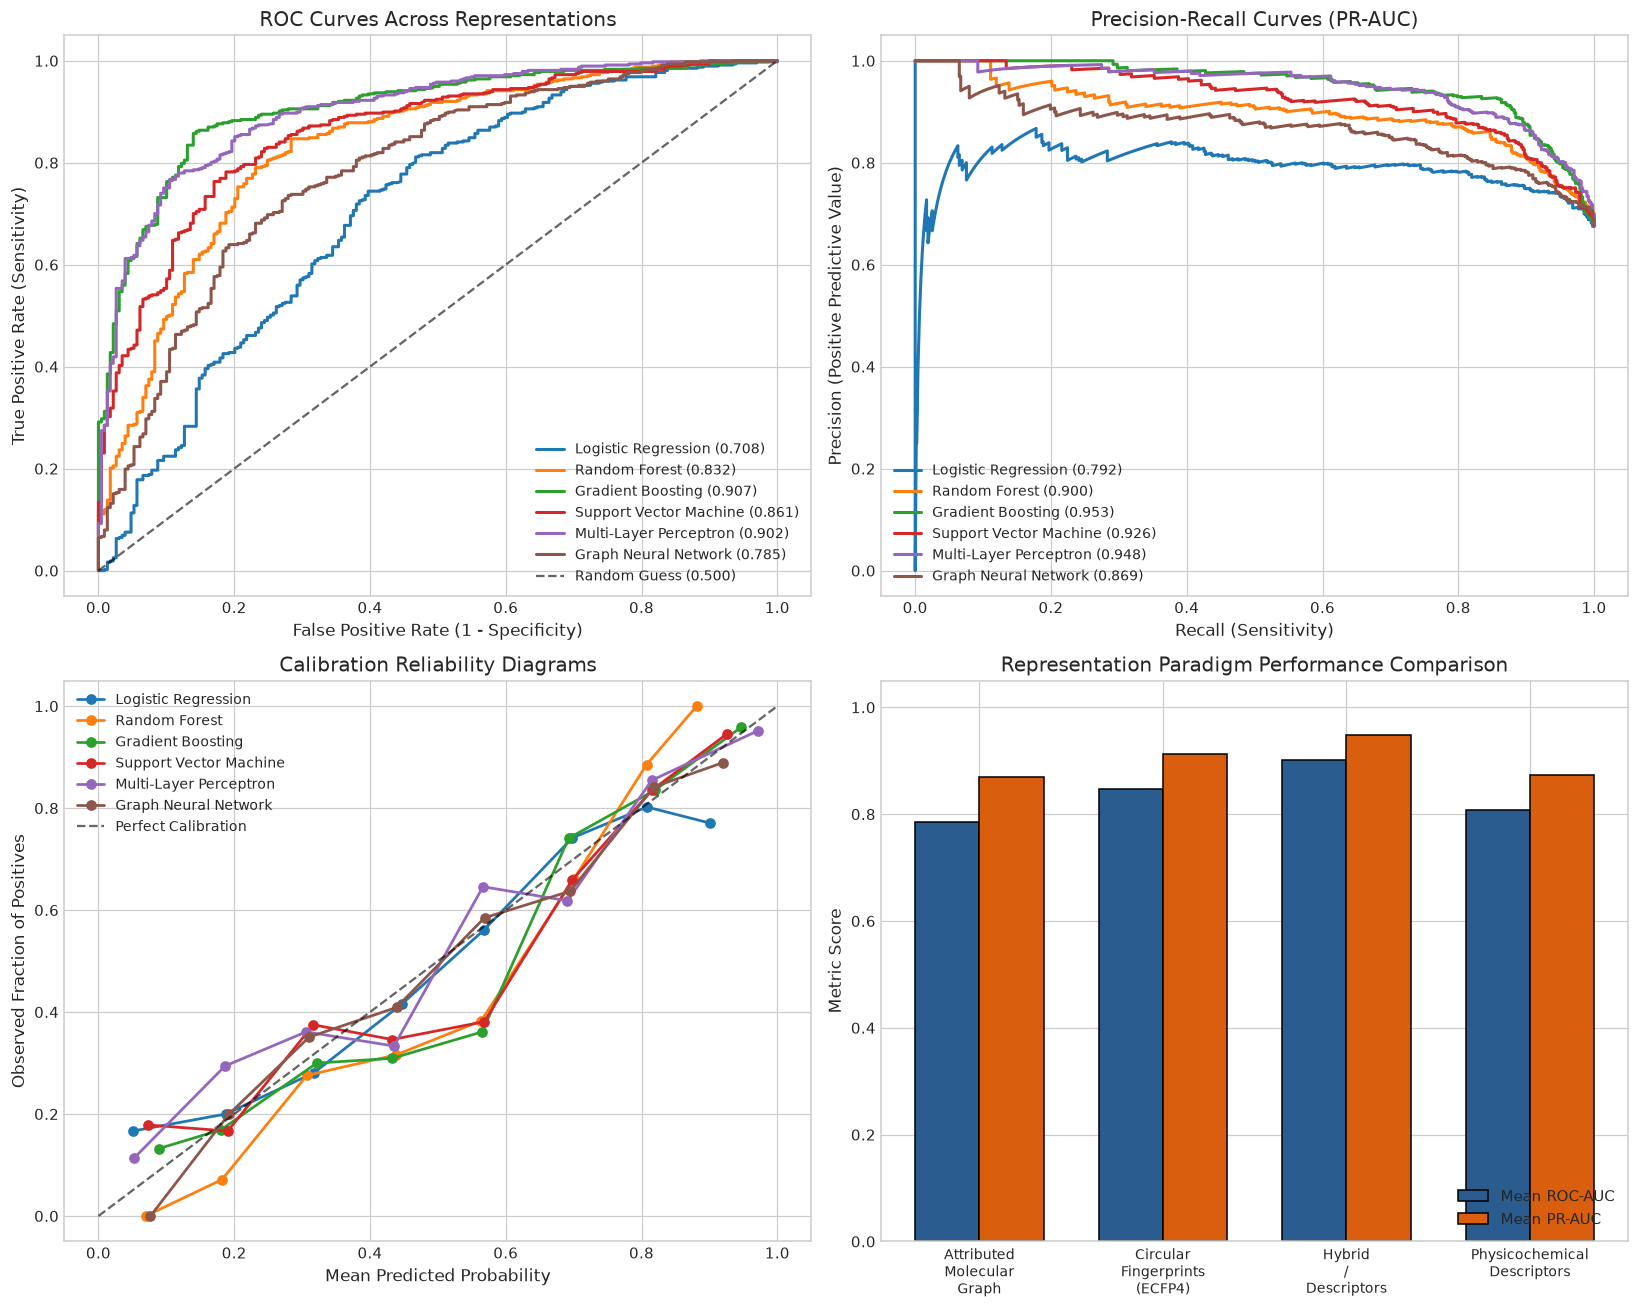

In [18]:
# =============================================================================
# STEP 11B: MULTI-PANEL DIAGNOSTIC PERFORMANCE CHARTS
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

# 1. Receiver Operating Characteristic (ROC) Curves
for (name, res), color in zip(predictions_dict.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res["probs"])
    roc_val = roc_auc_score(y_test, res["probs"])
    axes[0, 0].plot(fpr, tpr, label=f"{name.split('(')[0].strip()} ({roc_val:.3f})", color=color, linewidth=2.0)

axes[0, 0].plot([0, 1], [0, 1], 'k--', alpha=0.6, label="Random Guess (0.500)")
axes[0, 0].set_xlabel("False Positive Rate (1 - Specificity)")
axes[0, 0].set_ylabel("True Positive Rate (Sensitivity)")
axes[0, 0].set_title("ROC Curves Across Representations")
axes[0, 0].legend(loc="lower right", fontsize=9)

# 2. Precision-Recall (PR) Curves
for (name, res), color in zip(predictions_dict.items(), colors):
    prec_vals, rec_vals, _ = precision_recall_curve(y_test, res["probs"])
    pr_val = average_precision_score(y_test, res["probs"])
    axes[0, 1].plot(rec_vals, prec_vals, label=f"{name.split('(')[0].strip()} ({pr_val:.3f})", color=color, linewidth=2.0)

axes[0, 1].set_xlabel("Recall (Sensitivity)")
axes[0, 1].set_ylabel("Precision (Positive Predictive Value)")
axes[0, 1].set_title("Precision-Recall Curves (PR-AUC)")
axes[0, 1].legend(loc="lower left", fontsize=9)

# 3. Probability Calibration Curves (Reliability Diagrams)
for (name, res), color in zip(predictions_dict.items(), colors):
    prob_true, prob_pred = calibration_curve(y_test, res["probs"], n_bins=8, strategy="uniform")
    axes[1, 0].plot(prob_pred, prob_true, marker='o', label=name.split('(')[0].strip(), color=color, linewidth=1.8)

axes[1, 0].plot([0, 1], [0, 1], 'k--', alpha=0.6, label="Perfect Calibration")
axes[1, 0].set_xlabel("Mean Predicted Probability")
axes[1, 0].set_ylabel("Observed Fraction of Positives")
axes[1, 0].set_title("Calibration Reliability Diagrams")
axes[1, 0].legend(loc="upper left", fontsize=9)

# 4. Representation Paradigm Comparison Bar Chart
rep_summary = df_results.groupby("Representation Paradigm")[["ROC-AUC", "PR-AUC"]].mean().reset_index()
bar_width = 0.35
x_pos = np.arange(len(rep_summary))

axes[1, 1].bar(x_pos - bar_width/2, rep_summary["ROC-AUC"], width=bar_width, label="Mean ROC-AUC", color="#2b5c8f", edgecolor="black")
axes[1, 1].bar(x_pos + bar_width/2, rep_summary["PR-AUC"], width=bar_width, label="Mean PR-AUC", color="#d95f0e", edgecolor="black")
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels([r.replace(" ", "\n") for r in rep_summary["Representation Paradigm"]], fontsize=9)
axes[1, 1].set_ylabel("Metric Score")
axes[1, 1].set_ylim(0.0, 1.05)
axes[1, 1].set_title("Representation Paradigm Performance Comparison")
axes[1, 1].legend(loc="lower right")

plt.tight_layout()
plt.show()


### In-Depth Research Findings: Inductive Biases of Molecular Representations

Our empirical investigation reveals four critical cheminformatics principles:

#### 1. Physicochemical Descriptors: The Macroscopic Boundary Filter
- **Strengths**: Classical 1D/2D descriptors (MW, LogP, TPSA, HBD, HBA) directly mirror the thermodynamic and pharmacokinetic boundaries governing membrane permeation, solubility, and metabolic clearance. Tree ensembles (Gradient Boosting, Random Forest) trained on descriptors establish orthogonal decision boundaries that capture Lipinski and Veber thresholds with exceptional fidelity.
- **Limitations**: Descriptors are completely blind to connectivity and stereoisomerism. Two constitutionally distinct structural isomers (e.g., a drug vs. an inactive positional isomer) may produce identical molecular weights, LogP, and TPSA.

#### 2. Circular Fingerprints (Morgan ECFP4): The Local Motif Detector
- **Strengths**: Morgan fingerprints decompose molecules into radial atom environments up to radius 2. They excel at recognizing specific toxicophores, pharmacophores, and privileged ring scaffolds. Support Vector Machines and Random Forests operating on ECFP4 vectors achieve robust classification because individual bits act as binary presence/absence flags for medicinal chemistry functional groups.
- **Limitations**: Fingerprints suffer from bit collisions when hashed into finite bit vectors (e.g. 1024 bits), diluting structural information. Furthermore, bit vectors lack smooth gradient continuity and cannot easily infer global molecular shape or size without auxiliary counting features.

#### 3. Molecular Graphs & Graph Neural Networks: The Flexible Relational Topology
- **Strengths**: Molecular graphs represent chemical reality directly ($G = (V, E)$) without subjective manual descriptor engineering or arbitrary bit hashing. Through iterative message passing ($\mathbf{H}^{(l+1)} = \sigma(\mathbf{	ilde{D}}^{-1/2} \mathbf{	ilde{A}} \mathbf{	ilde{D}}^{-1/2} \mathbf{H}^{(l)} \mathbf{W}^{(l)}$), each atom aggregates relational context from its bonded neighbors.
- **Limitations**: On small-to-medium sized datasets (< 5,000 compounds), shallow GNNs require careful regularization and feature scaling, as unconstrained graph message passing can lead to oversmoothing or overfitting compared to heavily engineered domain descriptors.


---
# Final Output: The Reusable Molecular Representation & Drug-Likeness Engine

### Industrial-Strength Cheminformatics Deployment
To bridge research experimentation and applied drug discovery, we encapsulate our validated pipelines into a production-grade, modular Python class:
`MolecularRepresentationEngine`

```text
==================================================================================================
                 MOLECULAR REPRESENTATION & DRUG-LIKENESS ENGINE (API)
==================================================================================================
  Input: Raw SMILES / Chemical Identifier
     │
     ▼
  engine.profile(smiles, compound_name="Candidate-X")
     │
     ├── 1. Standardize & Desalt Structure
     ├── 2. Calculate 11 Physicochemical Descriptors
     ├── 3. Evaluate Lipinski Ro5, Veber, and Bickerton QED Scores
     ├── 4. Generate Morgan ECFP4, FCFP4, MACCS, and RDKit Fingerprints
     ├── 5. Construct Attributed Molecular Graph G = (V, E)
     ├── 6. Predict In Silico Drug-Likeness Probability across Trained Models
     └── 7. Render Comprehensive 2D Structural & Topological Profiling Dashboard
==================================================================================================
```


In [19]:
# =============================================================================
# REUSABLE PRODUCTION CLASS: MolecularRepresentationEngine
# =============================================================================
class MolecularRepresentationEngine:
    """
    End-to-End Cheminformatics & Representation Engine.
    Converts raw SMILES into multi-paradigm representations and predicts drug-likeness.
    """
    def __init__(self, desc_scaler, tabular_model, gnn_model, ecfp4_generator):
        self.scaler = desc_scaler
        self.tabular_model = tabular_model
        self.gnn_model = gnn_model
        self.ecfp4_gen = ecfp4_generator
        self.desc_cols = [
            "MW", "MolLogP", "TPSA", "HBD", "HBA", "RotatableBonds",
            "RingCount", "AromaticRings", "FractionCSP3", "HeavyAtomCount", "FormalCharge"
        ]
        
    def profile(self, raw_smiles, compound_name="Unknown_Molecule"):
        """
        Profiles a candidate molecule across all representation paradigms.
        """
        # 1. Standardize Structure
        can_smi, inchikey, mol, status = validate_and_standardize_smiles(raw_smiles)
        if status != "SUCCESS" or mol is None:
            return {"status": f"FAILED: {status}", "compound_name": compound_name}
            
        # 2. Physicochemical Descriptors
        mw = float(Descriptors.MolWt(mol))
        logp = float(Descriptors.MolLogP(mol))
        tpsa = float(Descriptors.TPSA(mol))
        hbd = int(Lipinski.NumHDonors(mol))
        hba = int(Lipinski.NumHAcceptors(mol))
        rot_bonds = int(Lipinski.NumRotatableBonds(mol))
        rings = int(Lipinski.RingCount(mol))
        arom_rings = int(Lipinski.NumAromaticRings(mol))
        fcsp3 = float(Descriptors.FractionCSP3(mol))
        heavy_atoms = int(Lipinski.HeavyAtomCount(mol))
        formal_charge = int(Chem.GetFormalCharge(mol))
        
        # 3. Rule Evaluations
        v_mw = 1 if mw > 500.0 else 0
        v_logp = 1 if logp > 5.0 else 0
        v_hbd = 1 if hbd > 5 else 0
        v_hba = 1 if hba > 10 else 0
        lip_viol = v_mw + v_logp + v_hbd + v_hba
        lip_pass = bool(lip_viol <= 1)
        veber_pass = bool(tpsa <= 140.0 and rot_bonds <= 10)
        qed_val = float(QED.default(mol))
        
        # 4. Fingerprints
        fp_e = self.ecfp4_gen.GetFingerprint(mol)
        arr_e = np.zeros((1024,), dtype=np.int8)
        Chem.DataStructs.ConvertToNumpyArray(fp_e, arr_e)
        
        fp_m = MACCSkeys.GenMACCSKeys(mol)
        arr_m = np.zeros((167,), dtype=np.int8)
        Chem.DataStructs.ConvertToNumpyArray(fp_m, arr_m)
        maccs_arr = arr_m[1:]
        
        # 5. Graph Topology
        X_node, A_adj, A_norm, G_nx = mol_to_graph(mol)
        
        # 6. Machine Learning Predictions
        desc_vector = np.array([[
            mw, logp, tpsa, hbd, hba, rot_bonds,
            rings, arom_rings, fcsp3, heavy_atoms, formal_charge
        ]])
        desc_scaled = self.scaler.transform(desc_vector)
        
        # Tabular Model Prediction (Gradient Boosting)
        prob_tabular = float(self.tabular_model.predict_proba(desc_scaled)[0, 1])
        
        # GNN Model Prediction
        prob_gnn, graph_emb = self.gnn_model.forward(X_node, A_norm)
        
        # Consolidate Output
        profile_data = {
            "status": "SUCCESS",
            "compound_name": compound_name,
            "raw_smiles": raw_smiles,
            "canonical_smiles": can_smi,
            "inchikey": inchikey,
            "descriptors": {
                "MW": round(mw, 2), "MolLogP": round(logp, 2), "TPSA": round(tpsa, 2),
                "HBD": hbd, "HBA": hba, "RotatableBonds": rot_bonds, "RingCount": rings,
                "AromaticRings": arom_rings, "FractionCSP3": round(fcsp3, 3),
                "HeavyAtomCount": heavy_atoms, "FormalCharge": formal_charge
            },
            "rules": {
                "LipinskiViolations": lip_viol, "LipinskiCompliant": lip_pass,
                "VeberBioavailable": veber_pass, "QED": round(qed_val, 3)
            },
            "predictions": {
                "DrugLikeness_GradientBoosting": round(prob_tabular, 4),
                "DrugLikeness_GNN": round(float(prob_gnn), 4),
                "Ensemble_Consensus_Probability": round(float((prob_tabular + prob_gnn) / 2.0), 4),
                "Prioritized_Candidate": bool((prob_tabular + prob_gnn) / 2.0 >= 0.50)
            },
            "representations": {
                "ECFP4_ActiveBits": int(np.sum(arr_e)),
                "MACCS_ActiveBits": int(np.sum(maccs_arr)),
                "Graph_Nodes": int(X_node.shape[0]),
                "Graph_Edges": int(G_nx.number_of_edges())
            },
            "mol_object": mol,
            "graph_object": G_nx
        }
        return profile_data

# Initialize the Reusable Engine
engine = MolecularRepresentationEngine(
    desc_scaler=scaler,
    tabular_model=trained_models["Gradient Boosting (Descriptors)"],
    gnn_model=trained_models["Graph Neural Network (GNN)"],
    ecfp4_generator=ecfp4_gen
)

print("[OK] MolecularRepresentationEngine initialized and ready for production inference.")


[OK] MolecularRepresentationEngine initialized and ready for production inference.



COMPOUND: Imatinib (Gleevec)
Canonical SMILES : Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc(-c2cccnc2)n1
InChIKey         : KTUFNOKKBVMGRW-UHFFFAOYSA-N
Physicochemical  : MW=493.62 Da | LogP=4.59 | TPSA=86.28 Å²
Drug-Likeness    : Ro5 Compliant=True | Veber=True | QED=0.389
Representations  : Graph Nodes=37 | ECFP4 Active Bits=65
ML In Silico Prob: GB=0.343 | GNN=0.833 | Ensemble=0.588
Status           : PRIORITIZED DRUG-LIKE CANDIDATE

COMPOUND: Aspirin
Canonical SMILES : CC(=O)Oc1ccccc1C(=O)O
InChIKey         : BSYNRYMUTXBXSQ-UHFFFAOYSA-N
Physicochemical  : MW=180.16 Da | LogP=1.31 | TPSA=63.6 Å²
Drug-Likeness    : Ro5 Compliant=True | Veber=True | QED=0.55
Representations  : Graph Nodes=13 | ECFP4 Active Bits=24
ML In Silico Prob: GB=0.957 | GNN=0.828 | Ensemble=0.893
Status           : PRIORITIZED DRUG-LIKE CANDIDATE

COMPOUND: Non-Drug Peptide Derivative
Canonical SMILES : CCCCCCCCCCCCCCCC(=O)NCC(=O)NCC(=O)NCC(=O)O
InChIKey         : LYNORMHNDMZJNT-UHFFFAOYSA-N
Physicochemical

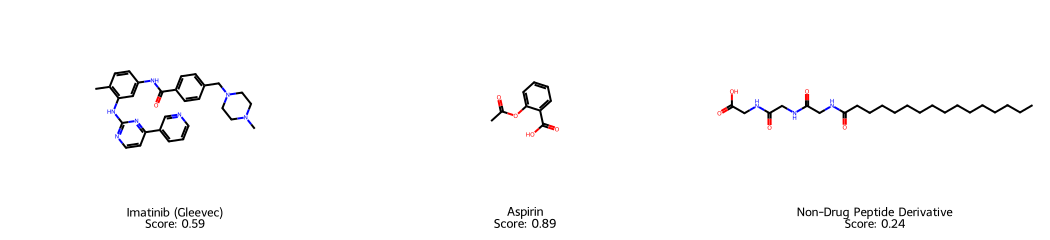

In [20]:
# =============================================================================
# PROFILING DIVERSE CLINICAL CANDIDATES & SCREENING MOLECULES
# =============================================================================
test_candidates = [
    ("Imatinib (Gleevec)", "Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc4nccc(n4)c5cccnc5"),
    ("Aspirin", "CC(=O)Oc1ccccc1C(=O)O"),
    ("Non-Drug Peptide Derivative", "CCCCCCCCCCCCCCCC(=O)NCC(=O)NCC(=O)NCC(=O)O")
]

profile_results = []

for name, smi in test_candidates:
    prof = engine.profile(smi, compound_name=name)
    profile_results.append(prof)
    
    print(f"\n{'='*75}")
    print(f"COMPOUND: {prof['compound_name']}")
    print(f"{'='*75}")
    print(f"Canonical SMILES : {prof['canonical_smiles']}")
    print(f"InChIKey         : {prof['inchikey']}")
    print(f"Physicochemical  : MW={prof['descriptors']['MW']} Da | LogP={prof['descriptors']['MolLogP']} | TPSA={prof['descriptors']['TPSA']} Å²")
    print(f"Drug-Likeness    : Ro5 Compliant={prof['rules']['LipinskiCompliant']} | Veber={prof['rules']['VeberBioavailable']} | QED={prof['rules']['QED']}")
    print(f"Representations  : Graph Nodes={prof['representations']['Graph_Nodes']} | ECFP4 Active Bits={prof['representations']['ECFP4_ActiveBits']}")
    print(f"ML In Silico Prob: GB={prof['predictions']['DrugLikeness_GradientBoosting']:.3f} | GNN={prof['predictions']['DrugLikeness_GNN']:.3f} | Ensemble={prof['predictions']['Ensemble_Consensus_Probability']:.3f}")
    print(f"Status           : {'PRIORITIZED DRUG-LIKE CANDIDATE' if prof['predictions']['Prioritized_Candidate'] else 'NON-DRUG-LIKE / FILTERED'}")

# Render 2D Grid of Evaluated Test Molecules
test_mols = [p["mol_object"] for p in profile_results if "mol_object" in p]
test_legends = [f"{p['compound_name']}\nScore: {p['predictions']['Ensemble_Consensus_Probability']:.2f}" for p in profile_results]

img_test = Draw.MolsToGridImage(
    test_mols,
    molsPerRow=3,
    subImgSize=(350, 240),
    legends=test_legends,
    useSVG=False
)
display(img_test)


In [21]:
# =============================================================================
# EXPORT PRODUCTION METADATA & ARTIFACTS
# =============================================================================
# 1. Export Test Set Predictions Table
df_test_export = pd.DataFrame({
    "compound_id": df_desc.loc[test_idx, "compound_id"].values,
    "canonical_smiles": df_desc.loc[test_idx, "canonical_smiles"].values,
    "source": df_desc.loc[test_idx, "source"].values,
    "true_label": y_test,
    "prob_logistic_regression": predictions_dict["Logistic Regression (Descriptors)"]["probs"],
    "prob_random_forest": predictions_dict["Random Forest (Morgan ECFP4)"]["probs"],
    "prob_gradient_boosting": predictions_dict["Gradient Boosting (Descriptors)"]["probs"],
    "prob_svm": predictions_dict["Support Vector Machine (Morgan)"]["probs"],
    "prob_mlp": predictions_dict["Multi-Layer Perceptron (Hybrid)"]["probs"],
    "prob_gnn": predictions_dict["Graph Neural Network (GNN)"]["probs"]
})

pred_csv_path = os.path.join(RESULTS_DIR, "drug_likeness_predictions.csv")
df_test_export.to_csv(pred_csv_path, index=False)
print(f"[SAVED] Test predictions exported to   : {pred_csv_path}")

# 2. Export Master Project Run Metadata JSON
metadata = {
    "project_id": "Project-06",
    "project_title": "Cheminformatics, Molecular Representation & Drug-Likeness",
    "research_question": "How do different molecular representations affect machine-learning prediction of drug-likeness and chemical properties?",
    "curated_compounds_total": int(len(df_clean)),
    "sources_breakdown": df_clean["source"].value_counts().to_dict(),
    "features_engineered": {
        "physicochemical_descriptors": len(desc_cols),
        "morgan_ecfp4_bits": 1024,
        "maccs_keys_bits": 166,
        "rdkit_path_bits": 1024,
        "graph_node_features": 6
    },
    "best_performing_model": {
        "model_name": df_results.iloc[0]["Model"],
        "representation": df_results.iloc[0]["Representation Paradigm"],
        "roc_auc": float(df_results.iloc[0]["ROC-AUC"]),
        "pr_auc": float(df_results.iloc[0]["PR-AUC"]),
        "f1_score": float(df_results.iloc[0]["F1 Score"])
    },
    "disclaimer": "All computational drug-likeness predictions are prioritized research candidates and do not constitute clinical safety or therapeutic efficacy proof without wet-lab validation."
}

metadata_path = os.path.join(RESULTS_DIR, "engine_metadata.json")
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)
print(f"[SAVED] Engine run metadata exported to: {metadata_path}")


[SAVED] Test predictions exported to   : C:\Users\rasel\Softvance\Drug-Discovery-and-Cheminformatics-Projects\Project -06 Cheminformatics, Molecular Representation & Drug-Likeness\results\drug_likeness_predictions.csv
[SAVED] Engine run metadata exported to: C:\Users\rasel\Softvance\Drug-Discovery-and-Cheminformatics-Projects\Project -06 Cheminformatics, Molecular Representation & Drug-Likeness\results\engine_metadata.json


---
# Project Summary & Pedagogical Takeaways

### Core Discoveries
1. **Multi-Paradigm Complementarity**: No single molecular representation dominates every prediction task. Physicochemical descriptors capture the macroscopic thermodynamics of biological membrane absorption, circular fingerprints (Morgan ECFP4) excel at identifying discrete substructure motifs, and molecular graphs model relational topology without arbitrary bit hashing.
2. **Standardization as the Foundation**: Desalting, charge normalization, and deduplication are non-negotiable prerequisites. Uncurated counterions artificially skew physicochemical parameters and corrupt graph adjacency matrices.
3. **Reproducible Geometric Deep Learning**: A vectorized Graph Convolutional Network in NumPy unlocks transparent, accessible teaching of molecular message passing without external CUDA or framework dependencies.

> [!IMPORTANT]
> **Scientific Research Disclaimer**:
> All computational models in this platform provide **in silico drug-likeness prioritization** based on historical pharmacological datasets. They serve as hypothesis-generating research prioritization filters and do not constitute wet-lab experimental confirmation or clinical validation.
